# CorrDiff + NASA FIRMS: Smokehouse Creek Fire

This streamlined notebook compares:

1. **CorrDiff 10 m wind at time T** on NVIDIA's official cropped HRRR Lambert-conformal output grid.
2. **NASA FIRMS detections from T through T+6 hours** as a forward validation window.
3. Individually titled PNG maps displayed vertically and saved for reuse.
4. An optional animated GIF assembled from the saved maps.

The Smokehouse Creek Fire began on February 26, 2024, roughly one mile north of Stinnett, Texas. The approximate ignition marker used here is `35.8478, -101.4325`. The study window focuses on the rapid eastward run on February 26, continued expansion on February 27, and the later wind shift and southward expansion.

The plotting box covers the main Smokehouse Creek growth corridor across the northeastern Texas Panhandle into western Oklahoma while excluding most of the separate Panhandle fires farther south and west. A geographic box cannot perfectly separate fires that merge or overlap, so inspect the FIRMS points before interpreting them as one continuous fire.

FIRMS points are active-heat detections, not exact fire perimeters or acreage.

**Run order:** execute each cell from top to bottom. Keep `RUN_CORRDIFF = False` until the NIM is running and you are ready to submit the timeline jobs.

Incident context:
- [InciWeb Smokehouse Creek update](https://inciweb.wildfire.gov/incident-publication/txtxs-smokehouse-creek-fire/smokehouse-creek-fire-daily-update%2C-11-p.m.02-27-2024)
- [CIMSS satellite analysis of the rapid fire runs](https://cimss.ssec.wisc.edu/satellite-blog/archives/57431)

In [1]:
# ============================================================
# 1. Imports and settings
# ============================================================

from datetime import datetime, timedelta
from getpass import getpass
from pathlib import Path
from zoneinfo import ZoneInfo
import io
import math
import os
import tarfile
import time as time_module

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch

from earth2studio.data import GEFS_FX, GEFS_FX_721x1440

# CorrDiff NIM service
NIM_BASE_URL = "http://corrdiff-nim-service-dylanhahn:8000"
NIM_HEALTH_URL = f"{NIM_BASE_URL}/v1/health/ready"
NIM_INFER_URL = f"{NIM_BASE_URL}/v1/infer"

# Approximate Smokehouse Creek Fire ignition marker
FIRE_NAME = "Smokehouse Creek Fire"
FIRE_LAT = 35.8478
FIRE_LON = -101.4325

# Main growth corridor: Stinnett, TX eastward into western Oklahoma.
# This excludes most of the separate fires farther south and west.
WEST, EAST = -102.00, -99.70
SOUTH, NORTH = 35.20, 36.20
FIRMS_BBOX = f"{WEST},{SOUTH},{EAST},{NORTH}"

# Rapid-growth timeline. The first 18Z frame is shortly before ignition,
# so its following six-hour FIRMS window includes the initial run.
VALID_TIMES = list(pd.date_range(
    start="2024-02-26 18:00",
    end="2024-02-29 00:00",
    freq="6h",
).to_pydatetime())

CORRDIFF_OUTPUT_DIR = Path("smokehouse_creek_corrdiff_outputs")
CORRDIFF_OUTPUT_DIR.mkdir(exist_ok=True)

# CorrDiff run settings
RUN_CORRDIFF = True
SAMPLES = 8
STEPS = 10
SEED = 0
OVERWRITE = False

# Official CorrDiff geographic coordinate files
GRID_DIR = Path("corrdiff_grid")
GRID_DIR.mkdir(exist_ok=True)
CORRDIFF_LAT_PATH = Path(os.environ.get(
    "CORRDIFF_LAT_PATH",
    GRID_DIR / "corrdiff_output_lat.npy",
))
CORRDIFF_LON_PATH = Path(os.environ.get(
    "CORRDIFF_LON_PATH",
    GRID_DIR / "corrdiff_output_lon.npy",
))
CORRDIFF_MODEL_VERSION = "1.0.0"
DOWNLOAD_GRID_IF_MISSING = True

# FIRMS settings. Standard-processing VIIRS sources are preferred for history.
FIRMS_CSV_PATH = None  # Example: "smokehouse_creek_firms_viirs.csv"
FIRMS_SOURCES = ["VIIRS_NOAA20_SP", "VIIRS_SNPP_SP"]
FIRMS_START_DATE = "2024-02-26"
FIRMS_END_DATE = "2024-02-29"

# Comparison and plot settings
LOCAL_TIMEZONE = "America/Chicago"
FUTURE_HOURS = 6
PREVIOUS_HISTORY_HOURS = 24
PLOT_ONLY_WINDOWS_WITH_FIRMS = True
PREVIOUS_POINT_SIZE = 2.5
FUTURE_POINT_SIZE = 8
STREAM_DENSITY = 1.05
STREAM_LINEWIDTH = 0.65
STREAM_ARROWSIZE = 0.85

# Static map outputs
PANEL_OUTPUT_DIR = Path("smokehouse_creek_corrdiff_firms_panels")
PANEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DISPLAY_ALL_PANELS = True
DISPLAY_WIDTH = 1000
PANEL_DPI = 220

print("Fire marker:", FIRE_LAT, FIRE_LON)
print("Map box:", FIRMS_BBOX)
print("CorrDiff runs:", len(VALID_TIMES))
for valid_time in VALID_TIMES:
    print(" ", valid_time.strftime("%Y-%m-%d %HZ"))

Fire marker: 35.8478 -101.4325
Map box: -102.0,35.2,-99.7,36.2
CorrDiff runs: 10
  2024-02-26 18Z
  2024-02-27 00Z
  2024-02-27 06Z
  2024-02-27 12Z
  2024-02-27 18Z
  2024-02-28 00Z
  2024-02-28 06Z
  2024-02-28 12Z
  2024-02-28 18Z
  2024-02-29 00Z


In [2]:
# ============================================================
# 2. CorrDiff input and inference helpers
# ============================================================

GEFS_SELECT_VARIABLES = [
    "u10m", "v10m", "t2m", "r2m", "sp", "msl", "tcwv",
]

GEFS_VARIABLES = [
    "u1000", "u925", "u850", "u700", "u500", "u250",
    "v1000", "v925", "v850", "v700", "v500", "v250",
    "z1000", "z925", "z850", "z700", "z500", "z200",
    "t1000", "t925", "t850", "t700", "t500", "t100",
    "r1000", "r925", "r850", "r700", "r500", "r100",
]

# cache=True prevents repeated downloads of the same GEFS files.
ds_gefs = GEFS_FX(cache=True)
ds_gefs_select = GEFS_FX_721x1440(cache=True, member="gec00")


def check_nim():
    try:
        response = requests.get(NIM_HEALTH_URL, timeout=30)
        print("NIM status:", response.status_code, response.text)
        return response.status_code == 200
    except Exception as exc:
        print("Could not reach CorrDiff NIM:", exc)
        return False


def fetch_input_gefs(init_time, lead_time, content_dtype="float32"):
    """Build the GEFS input array expected by the CorrDiff NIM."""
    dtype = np.dtype(getattr(np, content_dtype))
    gravity = np.array(9.80665, dtype=dtype)

    surface = ds_gefs_select(
        init_time,
        lead_time,
        GEFS_SELECT_VARIABLES,
    ).values

    # CorrDiff CONUS crop: lon 225-300 E, lat 21-53 N.
    surface = surface[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert surface.shape == (1, len(GEFS_SELECT_VARIABLES), 129, 301), surface.shape

    pressure = ds_gefs(init_time, lead_time, GEFS_VARIABLES)
    pressure = torch.nn.functional.interpolate(
        torch.as_tensor(pressure.values),
        (len(GEFS_VARIABLES), 721, 1440),
        mode="nearest",
    ).numpy()
    pressure = pressure[:, 0, :, 148:277, 900:1201].astype(dtype)
    assert pressure.shape == (1, len(GEFS_VARIABLES), 129, 301), pressure.shape

    z_variables = {"z1000", "z925", "z850", "z700", "z500", "z200"}
    z_indices = [
        index for index, variable in enumerate(GEFS_VARIABLES)
        if variable in z_variables
    ]
    pressure[:, z_indices, :, :] /= gravity

    lead_3hour_steps = int(lead_time.total_seconds() // (3 * 60 * 60))
    lead_field = lead_3hour_steps * np.ones((1, 1, 129, 301), dtype=dtype)

    return np.concatenate([surface, pressure, lead_field], axis=1)[None]


def init_and_lead(valid_time):
    """Use the same-day 00Z GEFS cycle; lead stays between 0 and 24 h."""
    init_time = datetime(valid_time.year, valid_time.month, valid_time.day, 0)
    lead_time = valid_time - init_time

    if not timedelta(0) <= lead_time <= timedelta(hours=24):
        raise ValueError(f"Unsupported lead time: {lead_time}")

    return init_time, lead_time


def output_path_for(valid_time):
    tag = valid_time.strftime("%Y%m%d_%HZ")
    return CORRDIFF_OUTPUT_DIR / f"smokehouse_creek_{tag}.tar"


def run_corrdiff(valid_time):
    output_path = output_path_for(valid_time)
    if output_path.exists() and not OVERWRITE:
        print("Skipping existing:", output_path)
        return output_path

    init_time, lead_time = init_and_lead(valid_time)
    input_path = CORRDIFF_OUTPUT_DIR / f"input_{valid_time:%Y%m%d_%HZ}.npy"

    print("\nValid:", valid_time.strftime("%Y-%m-%d %HZ"))
    print("GEFS init:", init_time.strftime("%Y-%m-%d %HZ"))
    print("Lead:", lead_time)

    input_array = fetch_input_gefs(init_time, lead_time)
    np.save(input_path, input_array)

    start_clock = time_module.perf_counter()
    with open(input_path, "rb") as input_file:
        response = requests.post(
            NIM_INFER_URL,
            headers={"accept": "application/x-tar"},
            data={"samples": SAMPLES, "steps": STEPS, "seed": SEED},
            files={"input_array": (input_path.name, input_file)},
            timeout=3000,
        )

    if response.status_code != 200:
        raise RuntimeError(
            f"CorrDiff failed: HTTP {response.status_code}\n{response.text[:1000]}"
        )

    output_path.write_bytes(response.content)
    elapsed = time_module.perf_counter() - start_clock
    print(f"Saved {output_path} in {elapsed:.1f} seconds")
    return output_path


check_nim()

Could not reach CorrDiff NIM: HTTPConnectionPool(host='corrdiff-nim-service-dylanhahn', port=8000): Max retries exceeded with url: /v1/health/ready (Caused by NewConnectionError("HTTPConnection(host='corrdiff-nim-service-dylanhahn', port=8000): Failed to establish a new connection: [Errno 111] Connection refused"))


False

In [3]:
# ============================================================
# 3. Run CorrDiff timeline
# ============================================================

if RUN_CORRDIFF:
    for valid_time in VALID_TIMES:
        try:
            run_corrdiff(valid_time)
        except Exception as exc:
            print("FAILED", valid_time.strftime("%Y-%m-%d %HZ"), exc)
else:
    print("RUN_CORRDIFF is False. No jobs were submitted.")
    print("Set RUN_CORRDIFF = True in the settings cell when ready.")

print("\nExpected output files:")
for valid_time in VALID_TIMES:
    print(valid_time.strftime("%Y-%m-%d %HZ"), "->", output_path_for(valid_time))

Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240226_18Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240227_00Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240227_06Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240227_12Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240227_18Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240228_00Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240228_06Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240228_12Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240228_18Z.tar
Skipping existing: smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240229_00Z.tar

Expected output files:
2024-02-26 18Z -> smokehouse_creek_corrdiff_outputs/smokehouse_creek_20240226_18Z.tar
2024-02-27 00Z -> sm

In [4]:
# ============================================================
# 4. Load CorrDiff wind outputs and official geographic grid
# ============================================================


def load_corrdiff_wind(tar_path):
    """Load all ensemble members and return ensemble-mean u10/v10."""
    u_members = []
    v_members = []

    with tarfile.open(tar_path) as archive:
        for member in archive.getmembers():
            if not member.isfile():
                continue

            extracted = archive.extractfile(member)
            if extracted is None:
                continue

            data = np.load(io.BytesIO(extracted.read()))
            u_members.append(data[0, 0, 0, :, :])
            v_members.append(data[0, 0, 1, :, :])

    if not u_members:
        raise ValueError(f"No arrays found in {tar_path}")

    u_mean = np.mean(u_members, axis=0).astype(np.float32)
    v_mean = np.mean(v_members, axis=0).astype(np.float32)
    return u_mean, v_mean


def download_ngc_model_file(filename, destination, api_key):
    """Download one coordinate file from the subscribed NVIDIA NGC model package."""
    url = (
        "https://api.ngc.nvidia.com/v2/org/nim/team/nvidia/models/"
        "earth2-corrdiff-us-gefs-hrrr/versions/"
        f"{CORRDIFF_MODEL_VERSION}/files/{filename}"
    )

    destination.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading official CorrDiff grid file:", filename)

    response = requests.get(
        url,
        headers={
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
        },
        timeout=300,
        allow_redirects=True,
    )

    if not response.ok:
        raise RuntimeError(
            f"Could not download {filename}: HTTP {response.status_code}.\n"
            f"Response: {response.text[:500]}"
        )

    destination.write_bytes(response.content)
    print("Saved:", destination)


def locate_grid_file(configured_path, filename):
    """Look in common notebook/model locations before downloading."""
    candidates = [
        configured_path,
        Path.cwd() / filename,
        CORRDIFF_OUTPUT_DIR / filename,
        Path.home() / filename,
        Path.home() / "corrdiff_grid" / filename,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    return configured_path


# Load CorrDiff outputs.
times = []
u_frames = []
v_frames = []

for valid_time in VALID_TIMES:
    tar_path = output_path_for(valid_time)
    if not tar_path.exists():
        print("Missing:", tar_path)
        continue

    u_mean, v_mean = load_corrdiff_wind(tar_path)
    times.append(valid_time.strftime("%Y-%m-%d %HZ"))
    u_frames.append(u_mean)
    v_frames.append(v_mean)

u_frames = np.asarray(u_frames, dtype=np.float32)
v_frames = np.asarray(v_frames, dtype=np.float32)

if len(times) == 0:
    raise ValueError(
        "No CorrDiff outputs were loaded. Run the timeline first or copy the tar files into "
        f"{CORRDIFF_OUTPUT_DIR}."
    )

# Find or download NVIDIA's official coordinate arrays.
lat_path = locate_grid_file(CORRDIFF_LAT_PATH, "corrdiff_output_lat.npy")
lon_path = locate_grid_file(CORRDIFF_LON_PATH, "corrdiff_output_lon.npy")

if DOWNLOAD_GRID_IF_MISSING and (not lat_path.exists() or not lon_path.exists()):
    ngc_api_key = os.environ.get("NGC_API_KEY") or os.environ.get("NGC_CLI_API_KEY")

    if not ngc_api_key:
        ngc_api_key = getpass(
            "Enter your NVIDIA NGC API key to download the official grid files: "
        ).strip()

    if not ngc_api_key:
        raise ValueError(
            "The official CorrDiff latitude/longitude files are missing. "
            "Set NGC_API_KEY, or place corrdiff_output_lat.npy and "
            "corrdiff_output_lon.npy inside the corrdiff_grid directory."
        )

    if not lat_path.exists():
        lat_path = CORRDIFF_LAT_PATH
        download_ngc_model_file("corrdiff_output_lat.npy", lat_path, ngc_api_key)

    if not lon_path.exists():
        lon_path = CORRDIFF_LON_PATH
        download_ngc_model_file("corrdiff_output_lon.npy", lon_path, ngc_api_key)

if not lat_path.exists() or not lon_path.exists():
    raise FileNotFoundError(
        "Missing official CorrDiff grid files. Place these files in corrdiff_grid/:\n"
        "  corrdiff_output_lat.npy\n"
        "  corrdiff_output_lon.npy"
    )

lat2d = np.asarray(np.load(lat_path), dtype=np.float64)
lon2d = np.asarray(np.load(lon_path), dtype=np.float64)
lon2d = np.where(lon2d > 180.0, lon2d - 360.0, lon2d)

expected_shape = u_frames.shape[-2:]
if lat2d.shape == expected_shape[::-1] and lon2d.shape == expected_shape[::-1]:
    lat2d = lat2d.T
    lon2d = lon2d.T

if lat2d.shape != expected_shape or lon2d.shape != expected_shape:
    raise ValueError(
        "CorrDiff coordinate shape does not match the wind output.\n"
        f"Wind shape: {expected_shape}\n"
        f"Latitude shape: {lat2d.shape}\n"
        f"Longitude shape: {lon2d.shape}"
    )

if not np.isfinite(lat2d).all() or not np.isfinite(lon2d).all():
    raise ValueError("The CorrDiff coordinate arrays contain invalid values.")

fire_inside_grid = (
    np.nanmin(lon2d) <= FIRE_LON <= np.nanmax(lon2d)
    and np.nanmin(lat2d) <= FIRE_LAT <= np.nanmax(lat2d)
)

print("Loaded CorrDiff frames:", len(times))
print("Wind shape:", u_frames.shape)
print("Coordinate files:")
print(" ", lat_path)
print(" ", lon_path)
print(
    "Grid bounds:",
    f"lon {np.nanmin(lon2d):.2f} to {np.nanmax(lon2d):.2f},",
    f"lat {np.nanmin(lat2d):.2f} to {np.nanmax(lat2d):.2f}",
)
print("Loaded times:", times)
print("Fire inside official CorrDiff grid:", fire_inside_grid)

Loaded CorrDiff frames: 10
Wind shape: (10, 1056, 1792)
Coordinate files:
  /home/jovyan/Fires/corrdiff_grid/corrdiff_output_lat.npy
  /home/jovyan/Fires/corrdiff_grid/corrdiff_output_lon.npy
Grid bounds: lon -133.92 to -61.06, lat 21.19 to 52.56
Loaded times: ['2024-02-26 18Z', '2024-02-27 00Z', '2024-02-27 06Z', '2024-02-27 12Z', '2024-02-27 18Z', '2024-02-28 00Z', '2024-02-28 06Z', '2024-02-28 12Z', '2024-02-28 18Z', '2024-02-29 00Z']
Fire inside official CorrDiff grid: True


In [5]:
# ============================================================
# 5. Download and clean NASA FIRMS detections
# ============================================================


def date_chunks(start_date, end_date, max_days=5):
    current = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)

    while current <= end:
        remaining = (end - current).days + 1
        day_range = min(max_days, remaining)
        yield current.strftime("%Y-%m-%d"), day_range
        current += pd.Timedelta(days=day_range)


def download_firms_source(map_key, source):
    chunks = []

    for chunk_start, day_range in date_chunks(FIRMS_START_DATE, FIRMS_END_DATE):
        url = (
            "https://firms.modaps.eosdis.nasa.gov/api/area/csv/"
            f"{map_key}/{source}/{FIRMS_BBOX}/{day_range}/{chunk_start}"
        )

        print("Downloading", source, chunk_start, "for", day_range, "day(s)")
        response = requests.get(url, timeout=120)

        if not response.ok:
            raise RuntimeError(
                f"{source} failed with HTTP {response.status_code}: "
                f"{response.text[:500]}"
            )

        text = response.text.strip()
        first_line = text.splitlines()[0] if text else ""
        if "latitude" not in first_line.lower():
            raise RuntimeError(f"Unexpected FIRMS response from {source}: {first_line}")

        chunk = pd.read_csv(io.StringIO(text))
        chunk["firms_source"] = source
        chunks.append(chunk)

    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()


def clean_firms(source_df):
    df = source_df.copy()
    df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
    df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")

    if "frp" in df.columns:
        df["frp"] = pd.to_numeric(df["frp"], errors="coerce").fillna(1.0)
    else:
        df["frp"] = 1.0

    date_text = df["acq_date"].astype(str).str.strip()
    time_text = (
        df["acq_time"]
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.extract(r"(\d{1,4})", expand=False)
        .str.zfill(4)
    )

    df["acq_datetime_utc"] = pd.to_datetime(
        date_text + " " + time_text,
        format="%Y-%m-%d %H%M",
        utc=True,
        errors="coerce",
    )

    df = df.dropna(subset=["latitude", "longitude", "acq_datetime_utc"])

    # Remove VIIRS low-confidence detections, but keep nominal/high.
    if "confidence" in df.columns:
        confidence = df["confidence"].astype(str).str.lower().str.strip()
        df = df[~confidence.isin(["l", "low"])].copy()

    df = df[
        (df["longitude"] >= WEST)
        & (df["longitude"] <= EAST)
        & (df["latitude"] >= SOUTH)
        & (df["latitude"] <= NORTH)
    ].copy()

    duplicate_columns = ["latitude", "longitude", "acq_datetime_utc"]
    if "firms_source" in df.columns:
        duplicate_columns.append("firms_source")

    return (
        df.drop_duplicates(subset=duplicate_columns)
        .sort_values("acq_datetime_utc")
        .reset_index(drop=True)
    )


if FIRMS_CSV_PATH:
    firms_raw = pd.read_csv(FIRMS_CSV_PATH)
    print("Loaded FIRMS CSV:", FIRMS_CSV_PATH)
else:
    map_key = os.environ.get("1da0d008f7fdb225eec2bd39e2281b1c")
    if not map_key:
        map_key = getpass("Enter NASA FIRMS MAP_KEY: ").strip()
    if not map_key:
        raise ValueError("A NASA FIRMS MAP_KEY is required.")

    source_frames = []
    for source in FIRMS_SOURCES:
        try:
            source_df = download_firms_source(map_key, source)
            print(source, "rows:", len(source_df))
            source_frames.append(source_df)
        except Exception as exc:
            print("WARNING:", source, "was skipped:", exc)

    if not source_frames:
        raise ValueError("No FIRMS source downloaded successfully.")

    firms_raw = pd.concat(source_frames, ignore_index=True)
    firms_raw.to_csv("smokehouse_creek_firms_viirs.csv", index=False)
    print("Saved smokehouse_creek_firms_viirs.csv")

fire_firms = clean_firms(firms_raw)

print("\nClean Smokehouse Creek FIRMS rows:", len(fire_firms))
if len(fire_firms) == 0:
    raise ValueError(
        "No FIRMS detections remained inside the Smokehouse Creek box. "
        "Check the date range, source, and coordinates."
    )

print(
    "FIRMS range:",
    fire_firms["acq_datetime_utc"].min(),
    "to",
    fire_firms["acq_datetime_utc"].max(),
)
print("\nCounts by UTC date:")
print(
    fire_firms["acq_datetime_utc"]
    .dt.strftime("%Y-%m-%d")
    .value_counts()
    .sort_index()
)
if "firms_source" in fire_firms.columns:
    print("\nCounts by source:")
    print(fire_firms["firms_source"].value_counts())

display(fire_firms.head())

Enter NASA FIRMS MAP_KEY:  ········


VIIRS_NOAA20_SP rows: 2886
VIIRS_SNPP_SP rows: 2892
Saved smokehouse_creek_firms_viirs.csv

Clean Smokehouse Creek FIRMS rows: 4927
FIRMS range: 2024-02-26 08:28:00+00:00 to 2024-02-29 09:12:00+00:00

Counts by UTC date:
acq_datetime_utc
2024-02-26     210
2024-02-27    3101
2024-02-28    1605
2024-02-29      11
Name: count, dtype: int64

Counts by source:
firms_source
VIIRS_NOAA20_SP    2487
VIIRS_SNPP_SP      2440
Name: count, dtype: int64


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,type,firms_source,acq_datetime_utc
0,35.66476,-101.43700,298.06,0.40,0.37,2024-02-26,828,N,VIIRS,n,2,281.27,0.75,N,2,VIIRS_SNPP_SP,2024-02-26 08:28:00+00:00
1,35.85582,-101.42908,338.15,0.39,0.36,2024-02-26,1948,N,VIIRS,n,2,283.61,3.96,D,0,VIIRS_SNPP_SP,2024-02-26 19:48:00+00:00
2,35.85769,-101.41631,352.62,0.39,0.36,2024-02-26,1948,N,VIIRS,n,2,281.91,10.53,D,0,VIIRS_SNPP_SP,2024-02-26 19:48:00+00:00
3,35.85726,-101.37757,344.71,0.39,0.36,2024-02-26,1948,N,VIIRS,n,2,274.35,6.06,D,0,VIIRS_SNPP_SP,2024-02-26 19:48:00+00:00
4,35.85707,-101.42056,341.59,0.39,0.36,2024-02-26,1948,N,VIIRS,n,2,281.00,10.53,D,0,VIIRS_SNPP_SP,2024-02-26 19:48:00+00:00


## Interpretation

For each retained panel:

- The colored background is the **CorrDiff ensemble-mean 10 m wind speed at time T**.
- Black streamlines show the predicted wind flow after the native curvilinear CorrDiff field is interpolated to a regular plotting grid.
- Light-gray dots are FIRMS detections from the previous 24 hours.
- Red dots are FIRMS detections observed from **T through T+6 hours**.
- The cyan star is the approximate ignition location.

The red points are not guaranteed to be newly burned land. They may include persistent heat, repeat overpasses, interior burning, or detections from another nearby fire that entered the geographic box.

In [6]:
# ============================================================
# 6. Prepare forward windows, map helpers, and shared scale
# ============================================================

DATA_CRS = ccrs.PlateCarree()
MAP_CRS = ccrs.PlateCarree()
LOCAL_TZ = ZoneInfo(LOCAL_TIMEZONE)


def label_to_utc(label):
    """Convert a label such as '2024-02-26 18Z' to a UTC Timestamp."""
    text = str(label).strip()
    if text.endswith("Z"):
        text = text[:-1]
    return pd.to_datetime(text, format="%Y-%m-%d %H", utc=True)


def format_local_time(timestamp):
    local = timestamp.tz_convert(LOCAL_TZ)
    return local.strftime("%a %b %d, %I:%M %p %Z").replace(" 0", " ")


def format_local_window(start, end):
    start_local = start.tz_convert(LOCAL_TZ)
    end_local = end.tz_convert(LOCAL_TZ)

    start_text = start_local.strftime("%a %b %d, %I:%M %p").replace(" 0", " ")
    if start_local.date() == end_local.date():
        end_text = end_local.strftime("%I:%M %p %Z").lstrip("0")
    else:
        end_text = end_local.strftime("%a %b %d, %I:%M %p %Z").replace(" 0", " ")

    return f"{start_text} - {end_text}"


def firms_forward_window(label):
    """Earlier FIRMS detections before T and detections during T to T+6 h."""
    start = label_to_utc(label)
    end = start + pd.Timedelta(hours=FUTURE_HOURS)
    history_start = start - pd.Timedelta(hours=PREVIOUS_HISTORY_HOURS)

    previous = fire_firms[
        (fire_firms["acq_datetime_utc"] >= history_start)
        & (fire_firms["acq_datetime_utc"] < start)
    ].copy()

    future = fire_firms[
        (fire_firms["acq_datetime_utc"] >= start)
        & (fire_firms["acq_datetime_utc"] < end)
    ].copy()

    return previous, future, start, end


def crop_wind(u, v, padding=2):
    """Crop the native curvilinear CorrDiff grid to the Smokehouse map box."""
    inside = (
        (lon2d >= WEST)
        & (lon2d <= EAST)
        & (lat2d >= SOUTH)
        & (lat2d <= NORTH)
    )

    if not inside.any():
        raise ValueError("The Smokehouse Creek map box does not overlap the CorrDiff grid.")

    rows, columns = np.where(inside)
    row_start = max(0, rows.min() - padding)
    row_end = min(lon2d.shape[0], rows.max() + padding + 1)
    col_start = max(0, columns.min() - padding)
    col_end = min(lon2d.shape[1], columns.max() + padding + 1)

    lon_zoom = lon2d[row_start:row_end, col_start:col_end]
    lat_zoom = lat2d[row_start:row_end, col_start:col_end]
    u_zoom = u[row_start:row_end, col_start:col_end]
    v_zoom = v[row_start:row_end, col_start:col_end]
    speed_mph = np.sqrt(u_zoom**2 + v_zoom**2) * 2.23694

    return lon_zoom, lat_zoom, u_zoom, v_zoom, speed_mph


def add_map_features(ax, show_left_labels=True, show_bottom_labels=True):
    """Add state lines and readable latitude/longitude labels."""
    ax.add_feature(
        cfeature.STATES.with_scale("10m"),
        linewidth=1.0,
        edgecolor="0.15",
        facecolor="none",
        zorder=8,
    )

    ax.add_feature(
        cfeature.BORDERS.with_scale("10m"),
        linewidth=0.8,
        edgecolor="0.25",
        facecolor="none",
        zorder=8,
    )

    gridlines = ax.gridlines(
        crs=DATA_CRS,
        draw_labels=True,
        linewidth=0.35,
        color="0.35",
        alpha=0.45,
        linestyle="--",
        x_inline=False,
        y_inline=False,
    )
    gridlines.top_labels = False
    gridlines.right_labels = False
    gridlines.left_labels = show_left_labels
    gridlines.bottom_labels = show_bottom_labels
    gridlines.xlabel_style = {"size": 8}
    gridlines.ylabel_style = {"size": 8}


# Summarize every loaded CorrDiff frame.
summary_rows = []
for label in times:
    previous, future, start, end = firms_forward_window(label)
    summary_rows.append({
        "label": label,
        "wind_valid_local": format_local_time(start),
        "firms_window_local": format_local_window(start, end),
        "earlier_points": len(previous),
        "following_points": len(future),
    })

window_summary = pd.DataFrame(summary_rows)
display(
    window_summary[[
        "wind_valid_local",
        "firms_window_local",
        "earlier_points",
        "following_points",
    ]].rename(columns={
        "wind_valid_local": "CorrDiff wind valid (Central time)",
        "firms_window_local": "FIRMS observation window (Central time)",
        "earlier_points": "Earlier FIRMS detections",
        "following_points": "FIRMS detections during following 6 h",
    })
)

labels_with_firms = window_summary.loc[
    window_summary["following_points"] > 0,
    "label",
].tolist()

if PLOT_ONLY_WINDOWS_WITH_FIRMS and labels_with_firms:
    selected_labels = labels_with_firms
else:
    selected_labels = list(times)
    if PLOT_ONLY_WINDOWS_WITH_FIRMS and not labels_with_firms:
        print("No forward windows contained FIRMS detections; plotting all wind frames.")

if not selected_labels:
    raise ValueError("There are no CorrDiff frames to plot.")

time_to_index = {label: index for index, label in enumerate(times)}

# One wind-speed scale for all panels.
wind_values = []
for label in selected_labels:
    frame_index = time_to_index[label]
    _, _, _, _, speed_zoom = crop_wind(
        u_frames[frame_index],
        v_frames[frame_index],
    )
    valid_speed = speed_zoom[np.isfinite(speed_zoom)]
    if valid_speed.size:
        wind_values.append(valid_speed)

if not wind_values:
    raise ValueError("No finite CorrDiff wind values were found inside the map box.")

wind_values = np.concatenate(wind_values)
vmax = max(10, math.ceil(np.nanpercentile(wind_values, 98) / 5) * 5)
levels = np.arange(0, vmax + 5, 5)

print("Selected panels:", len(selected_labels))
print("Shared wind-speed scale: 0 to", vmax, "mph")

,CorrDiff wind valid (Central time),FIRMS observation window (Central time),Earlier FIRMS detections,FIRMS detections during following 6 h
0,"Mon Feb 26, 12:00 PM CST","Mon Feb 26, 12:00 PM - 6:00 PM CST",1,209
1,"Mon Feb 26, 6:00 PM CST","Mon Feb 26, 6:00 PM - Tue Feb 27, 12:00 AM CST",210,0
2,"Tue Feb 27, 12:00 AM CST","Tue Feb 27, 12:00 AM - 6:00 AM CST",210,583
3,"Tue Feb 27, 6:00 AM CST","Tue Feb 27, 6:00 AM - 12:00 PM CST",792,0
4,"Tue Feb 27, 12:00 PM CST","Tue Feb 27, 12:00 PM - 6:00 PM CST",792,2518
5,"Tue Feb 27, 6:00 PM CST","Tue Feb 27, 6:00 PM - Wed Feb 28, 12:00 AM CST",3101,0
6,"Wed Feb 28, 12:00 AM CST","Wed Feb 28, 12:00 AM - 6:00 AM CST",3101,1101
7,"Wed Feb 28, 6:00 AM CST","Wed Feb 28, 6:00 AM - 12:00 PM CST",3619,0
8,"Wed Feb 28, 12:00 PM CST","Wed Feb 28, 12:00 PM - 6:00 PM CST",3619,504
9,"Wed Feb 28, 6:00 PM CST","Wed Feb 28, 6:00 PM - Thu Feb 29, 12:00 AM CST",1605,0


Selected panels: 5
Shared wind-speed scale: 0 to 40 mph


Saved 1/5: smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_2024-02-26_18Z.png


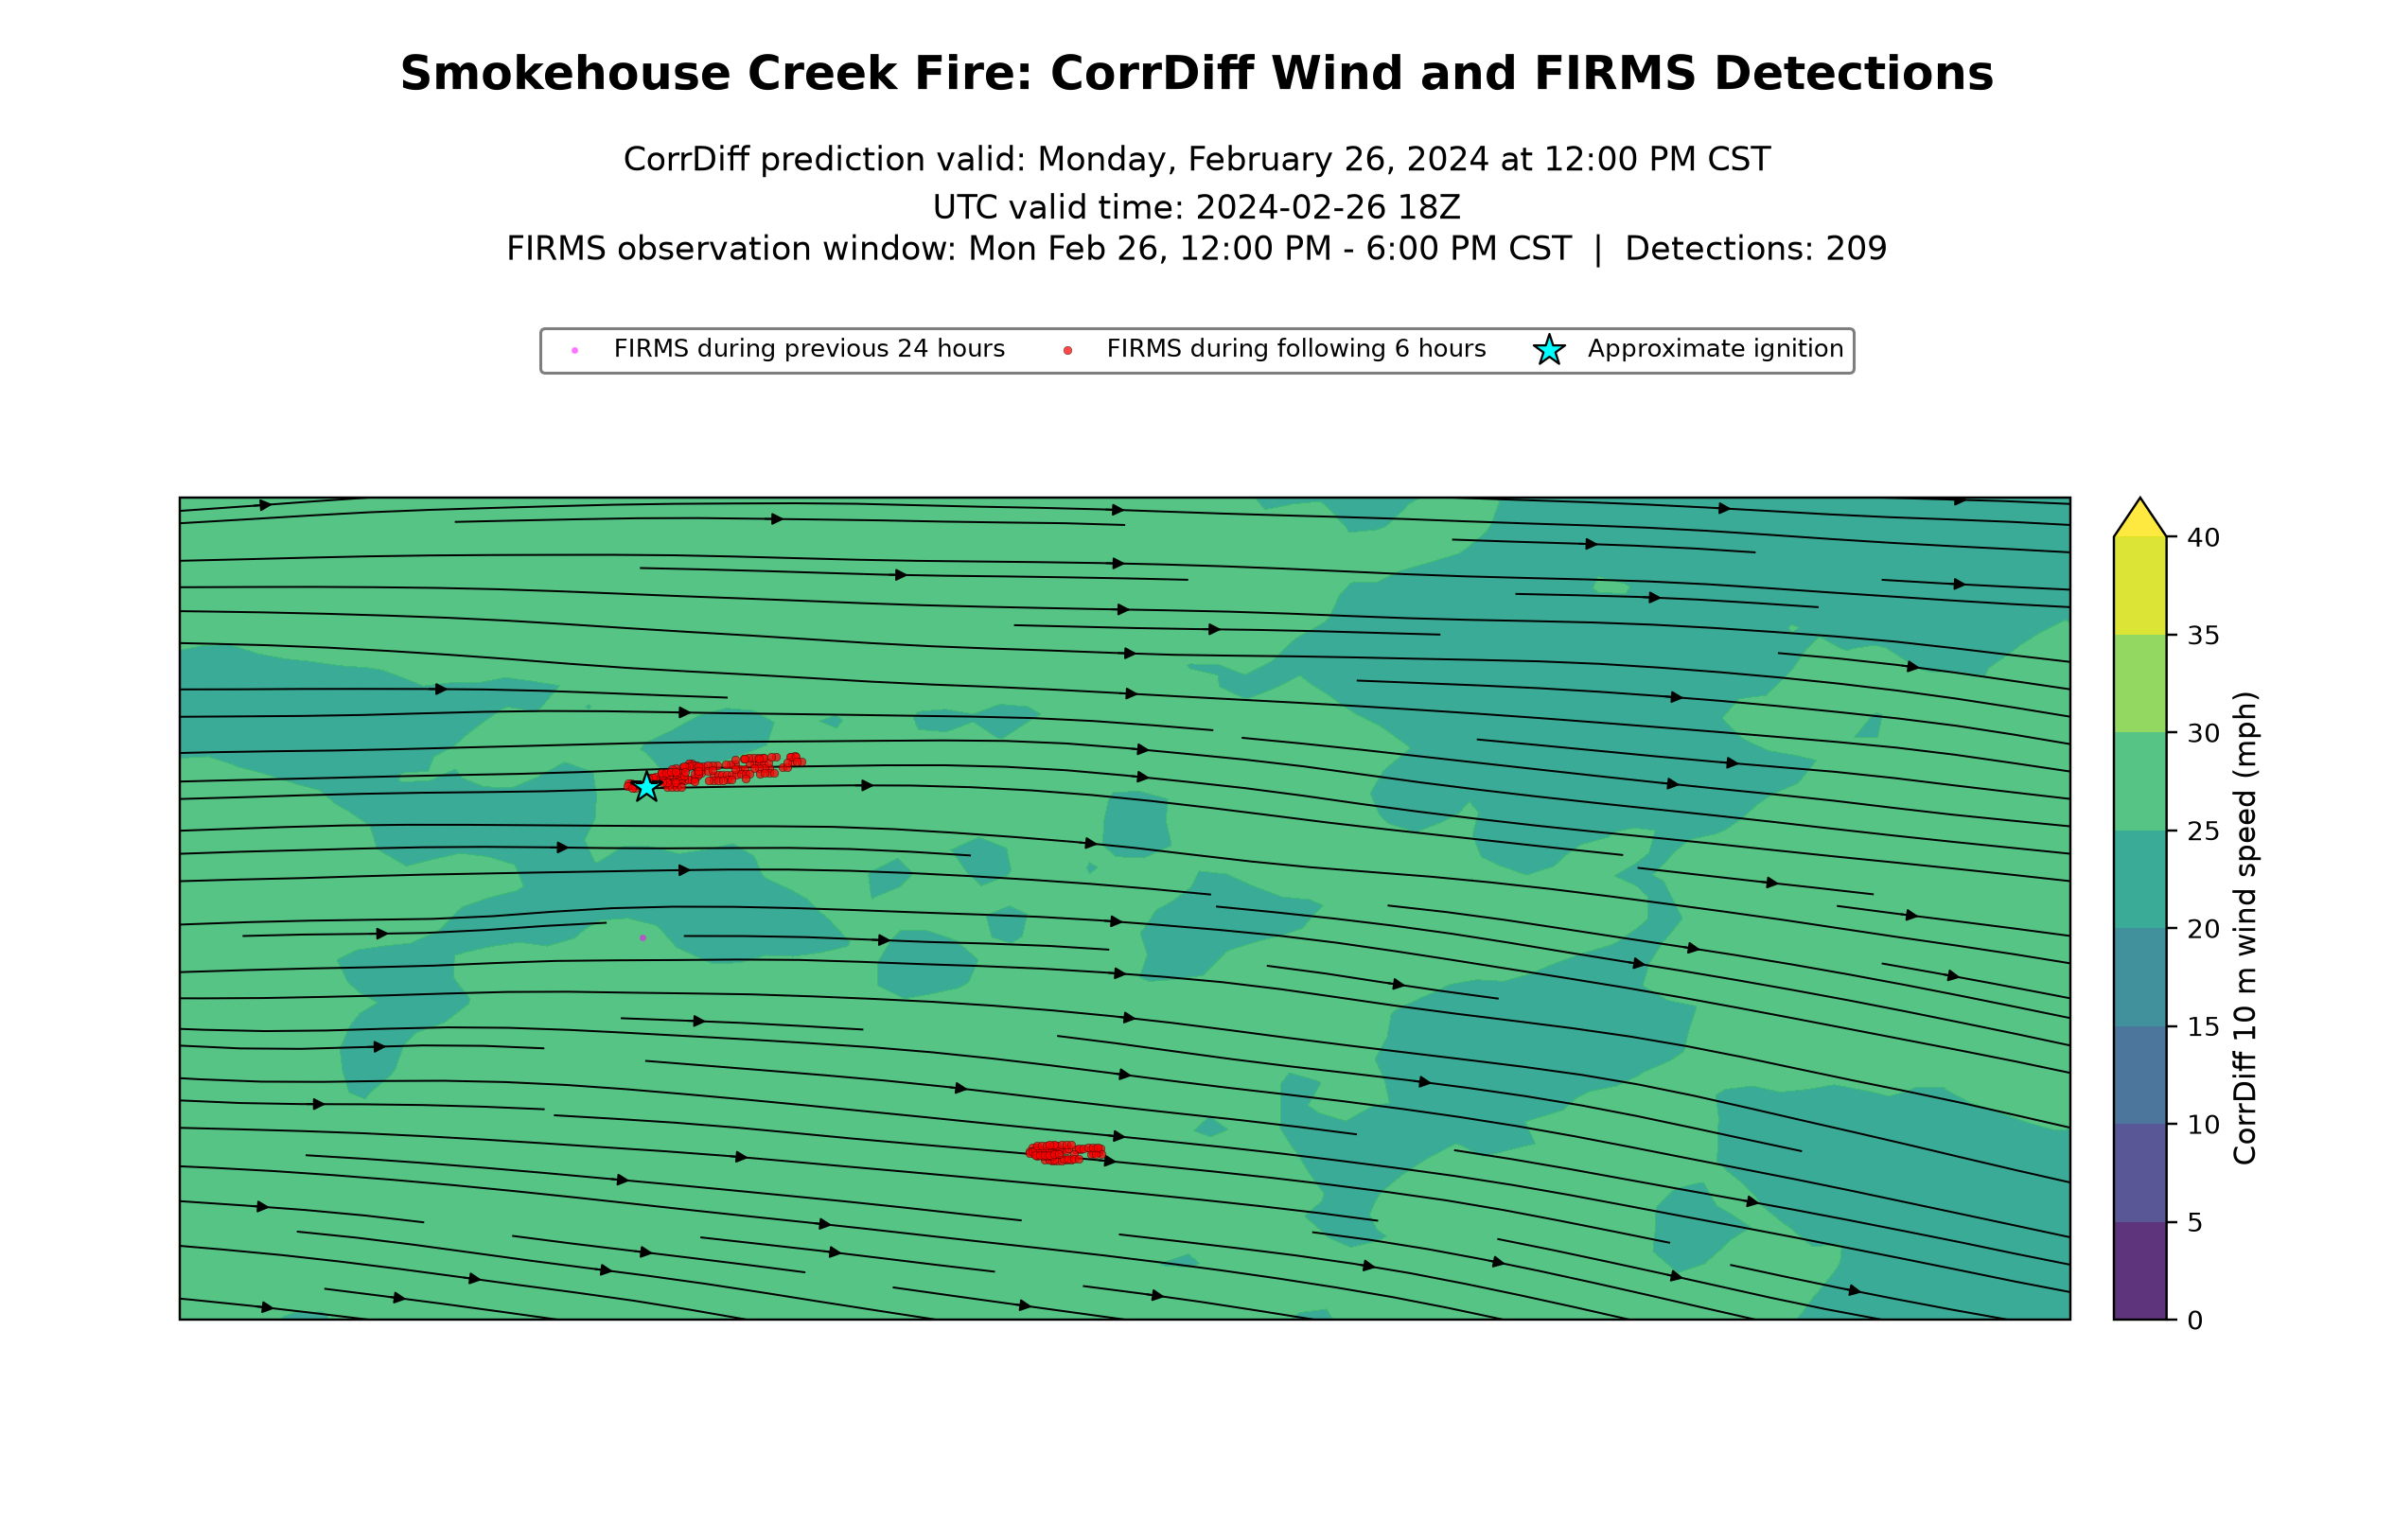

Saved 2/5: smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_2024-02-27_06Z.png


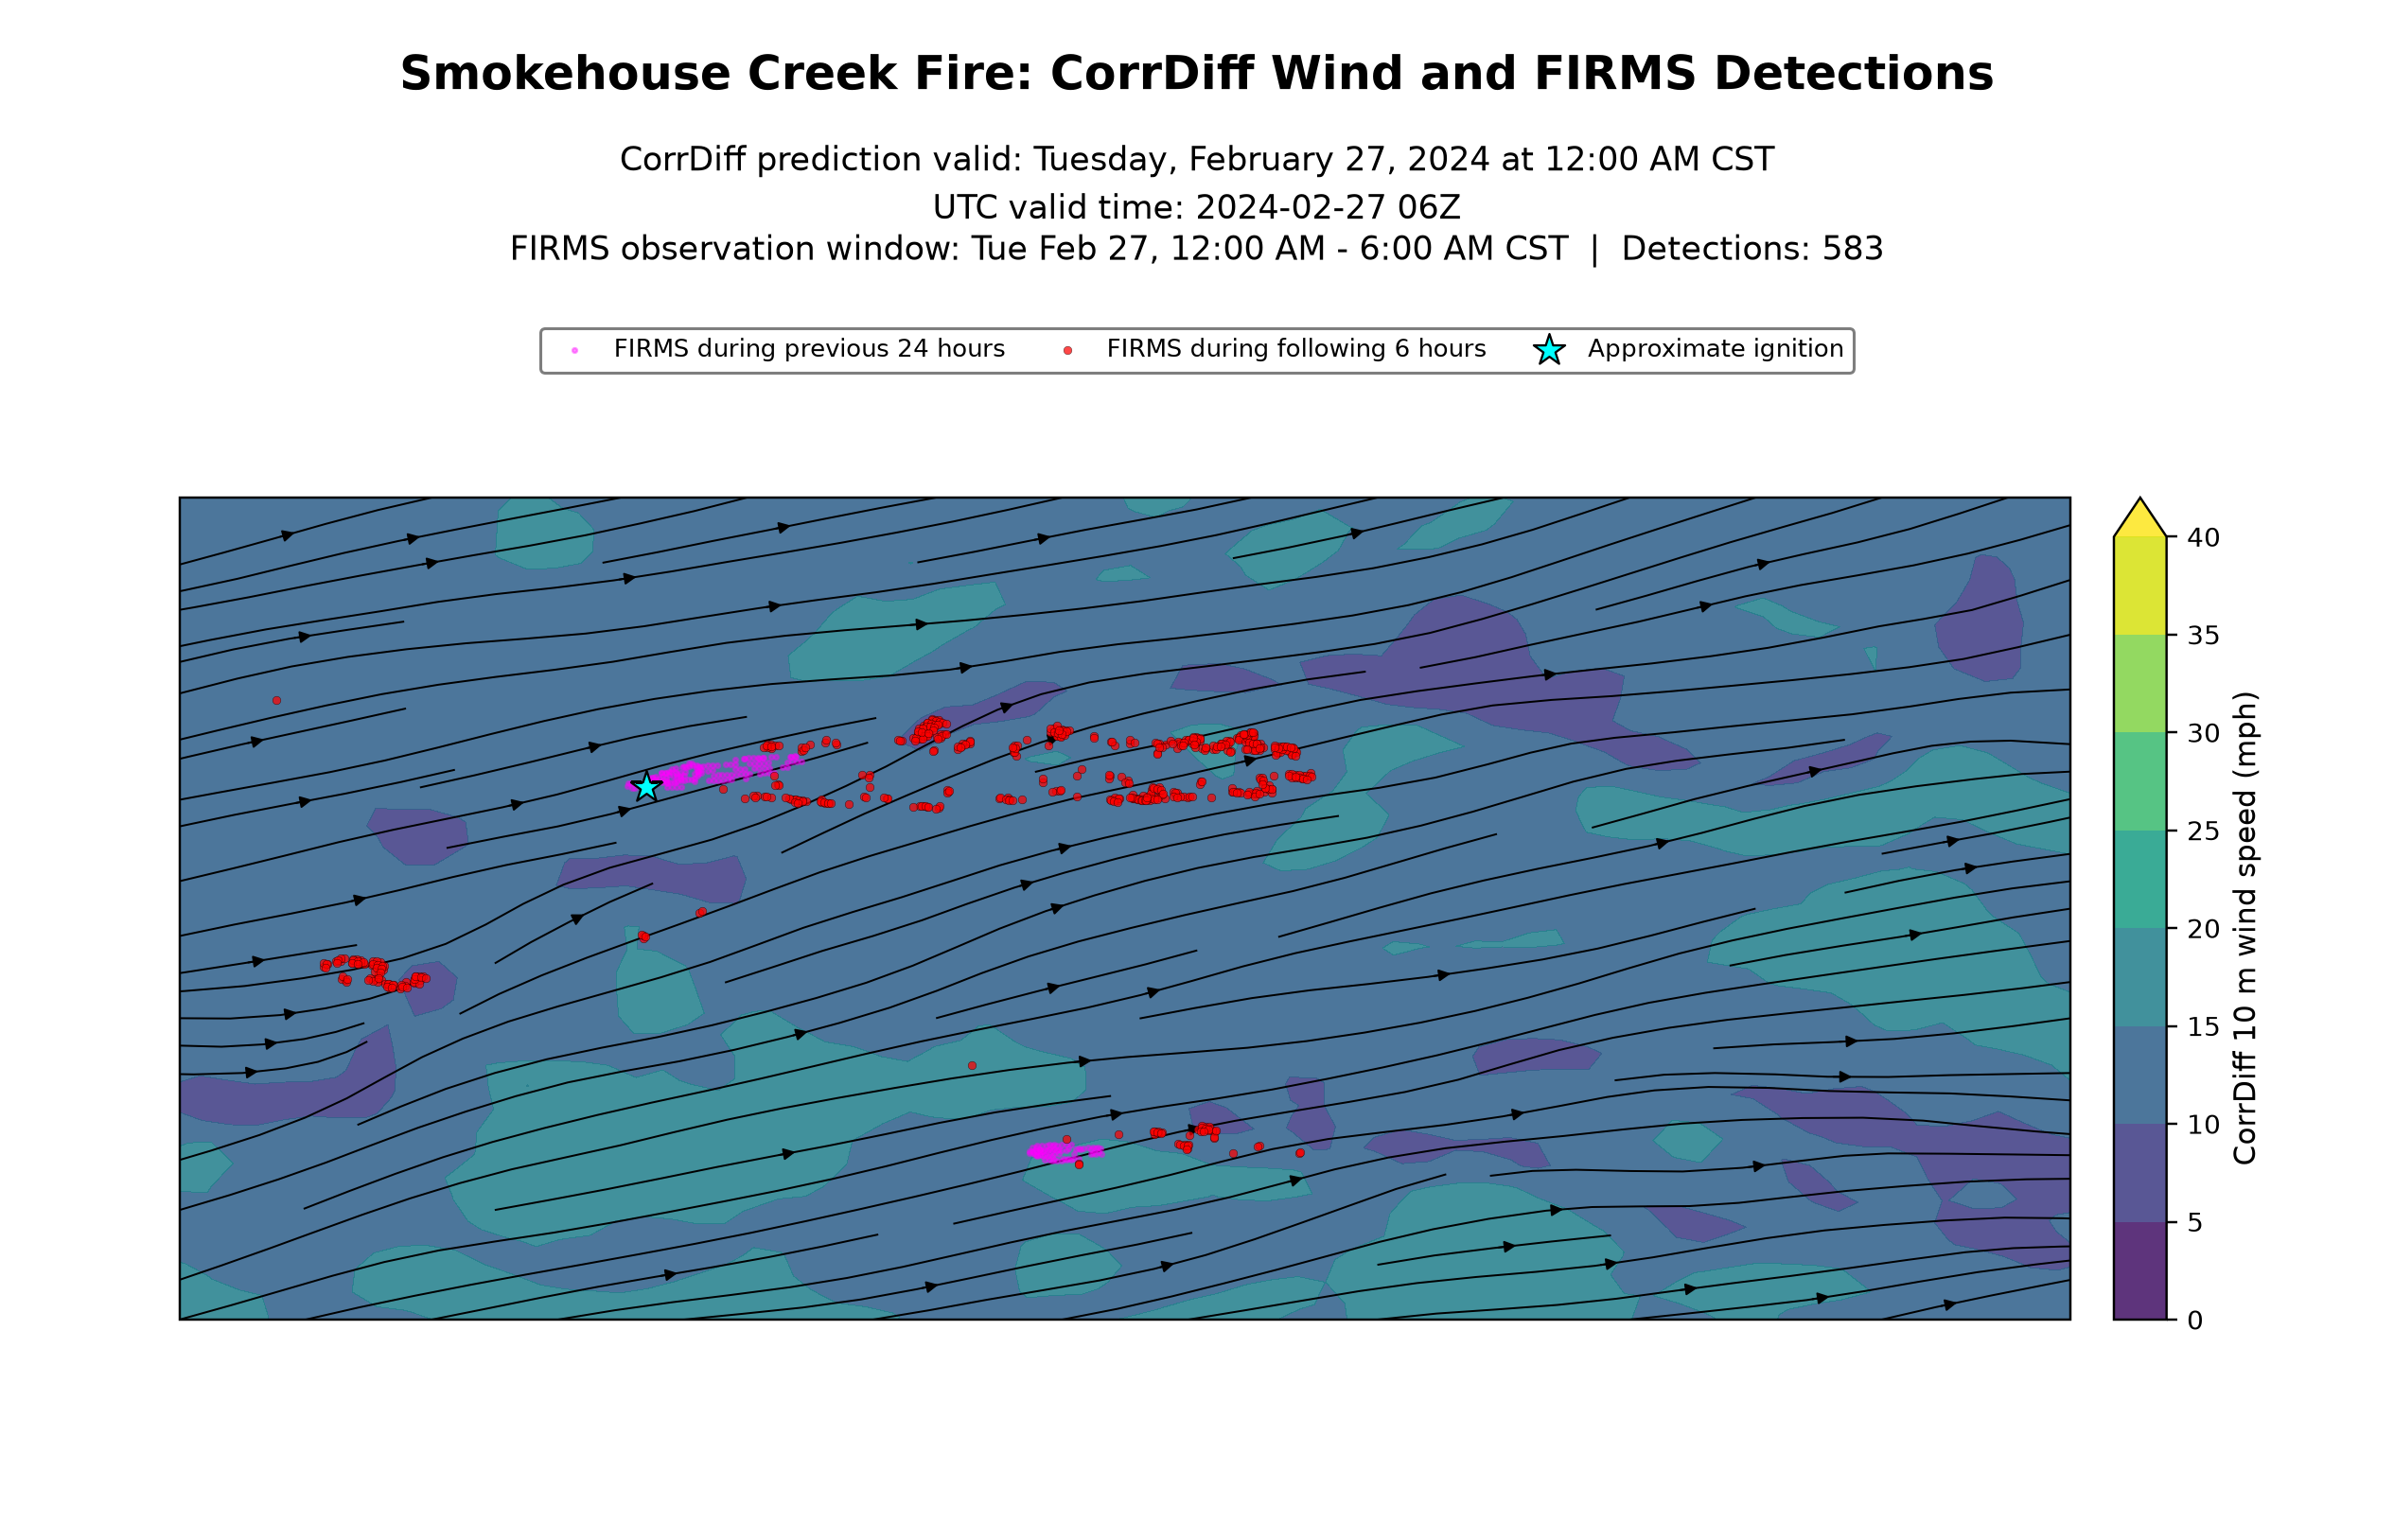

Saved 3/5: smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_2024-02-27_18Z.png


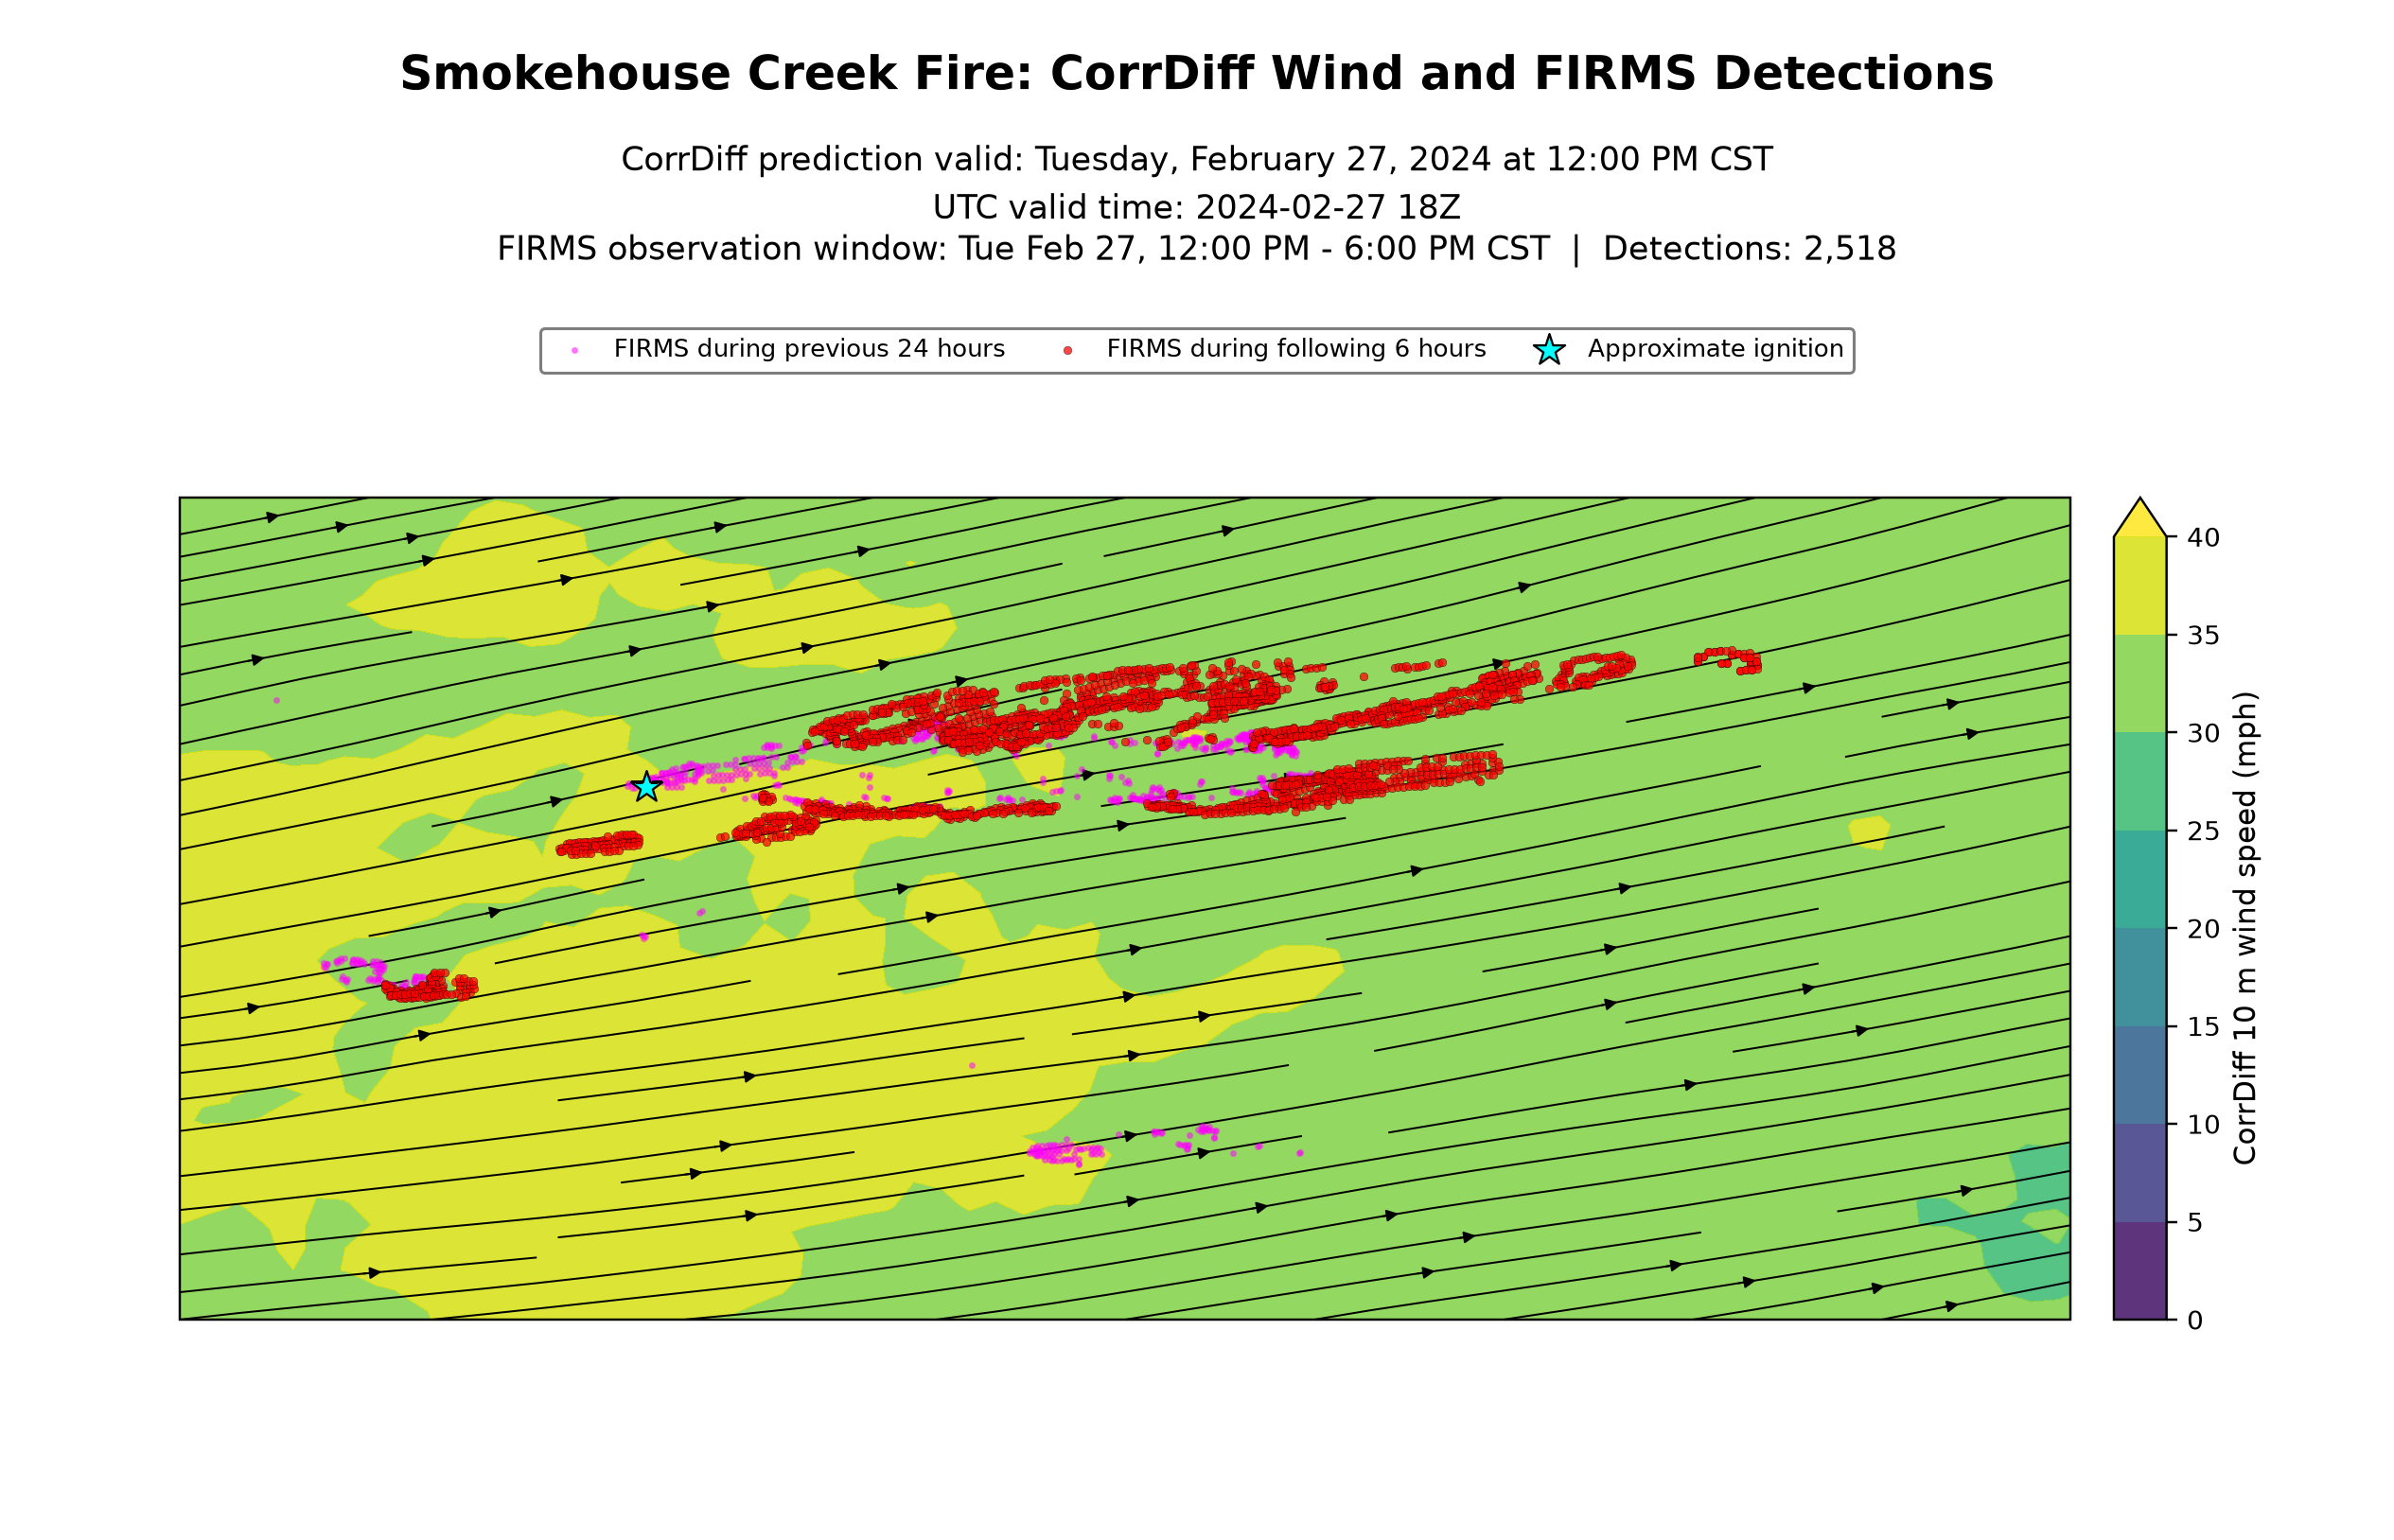

Saved 4/5: smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_2024-02-28_06Z.png


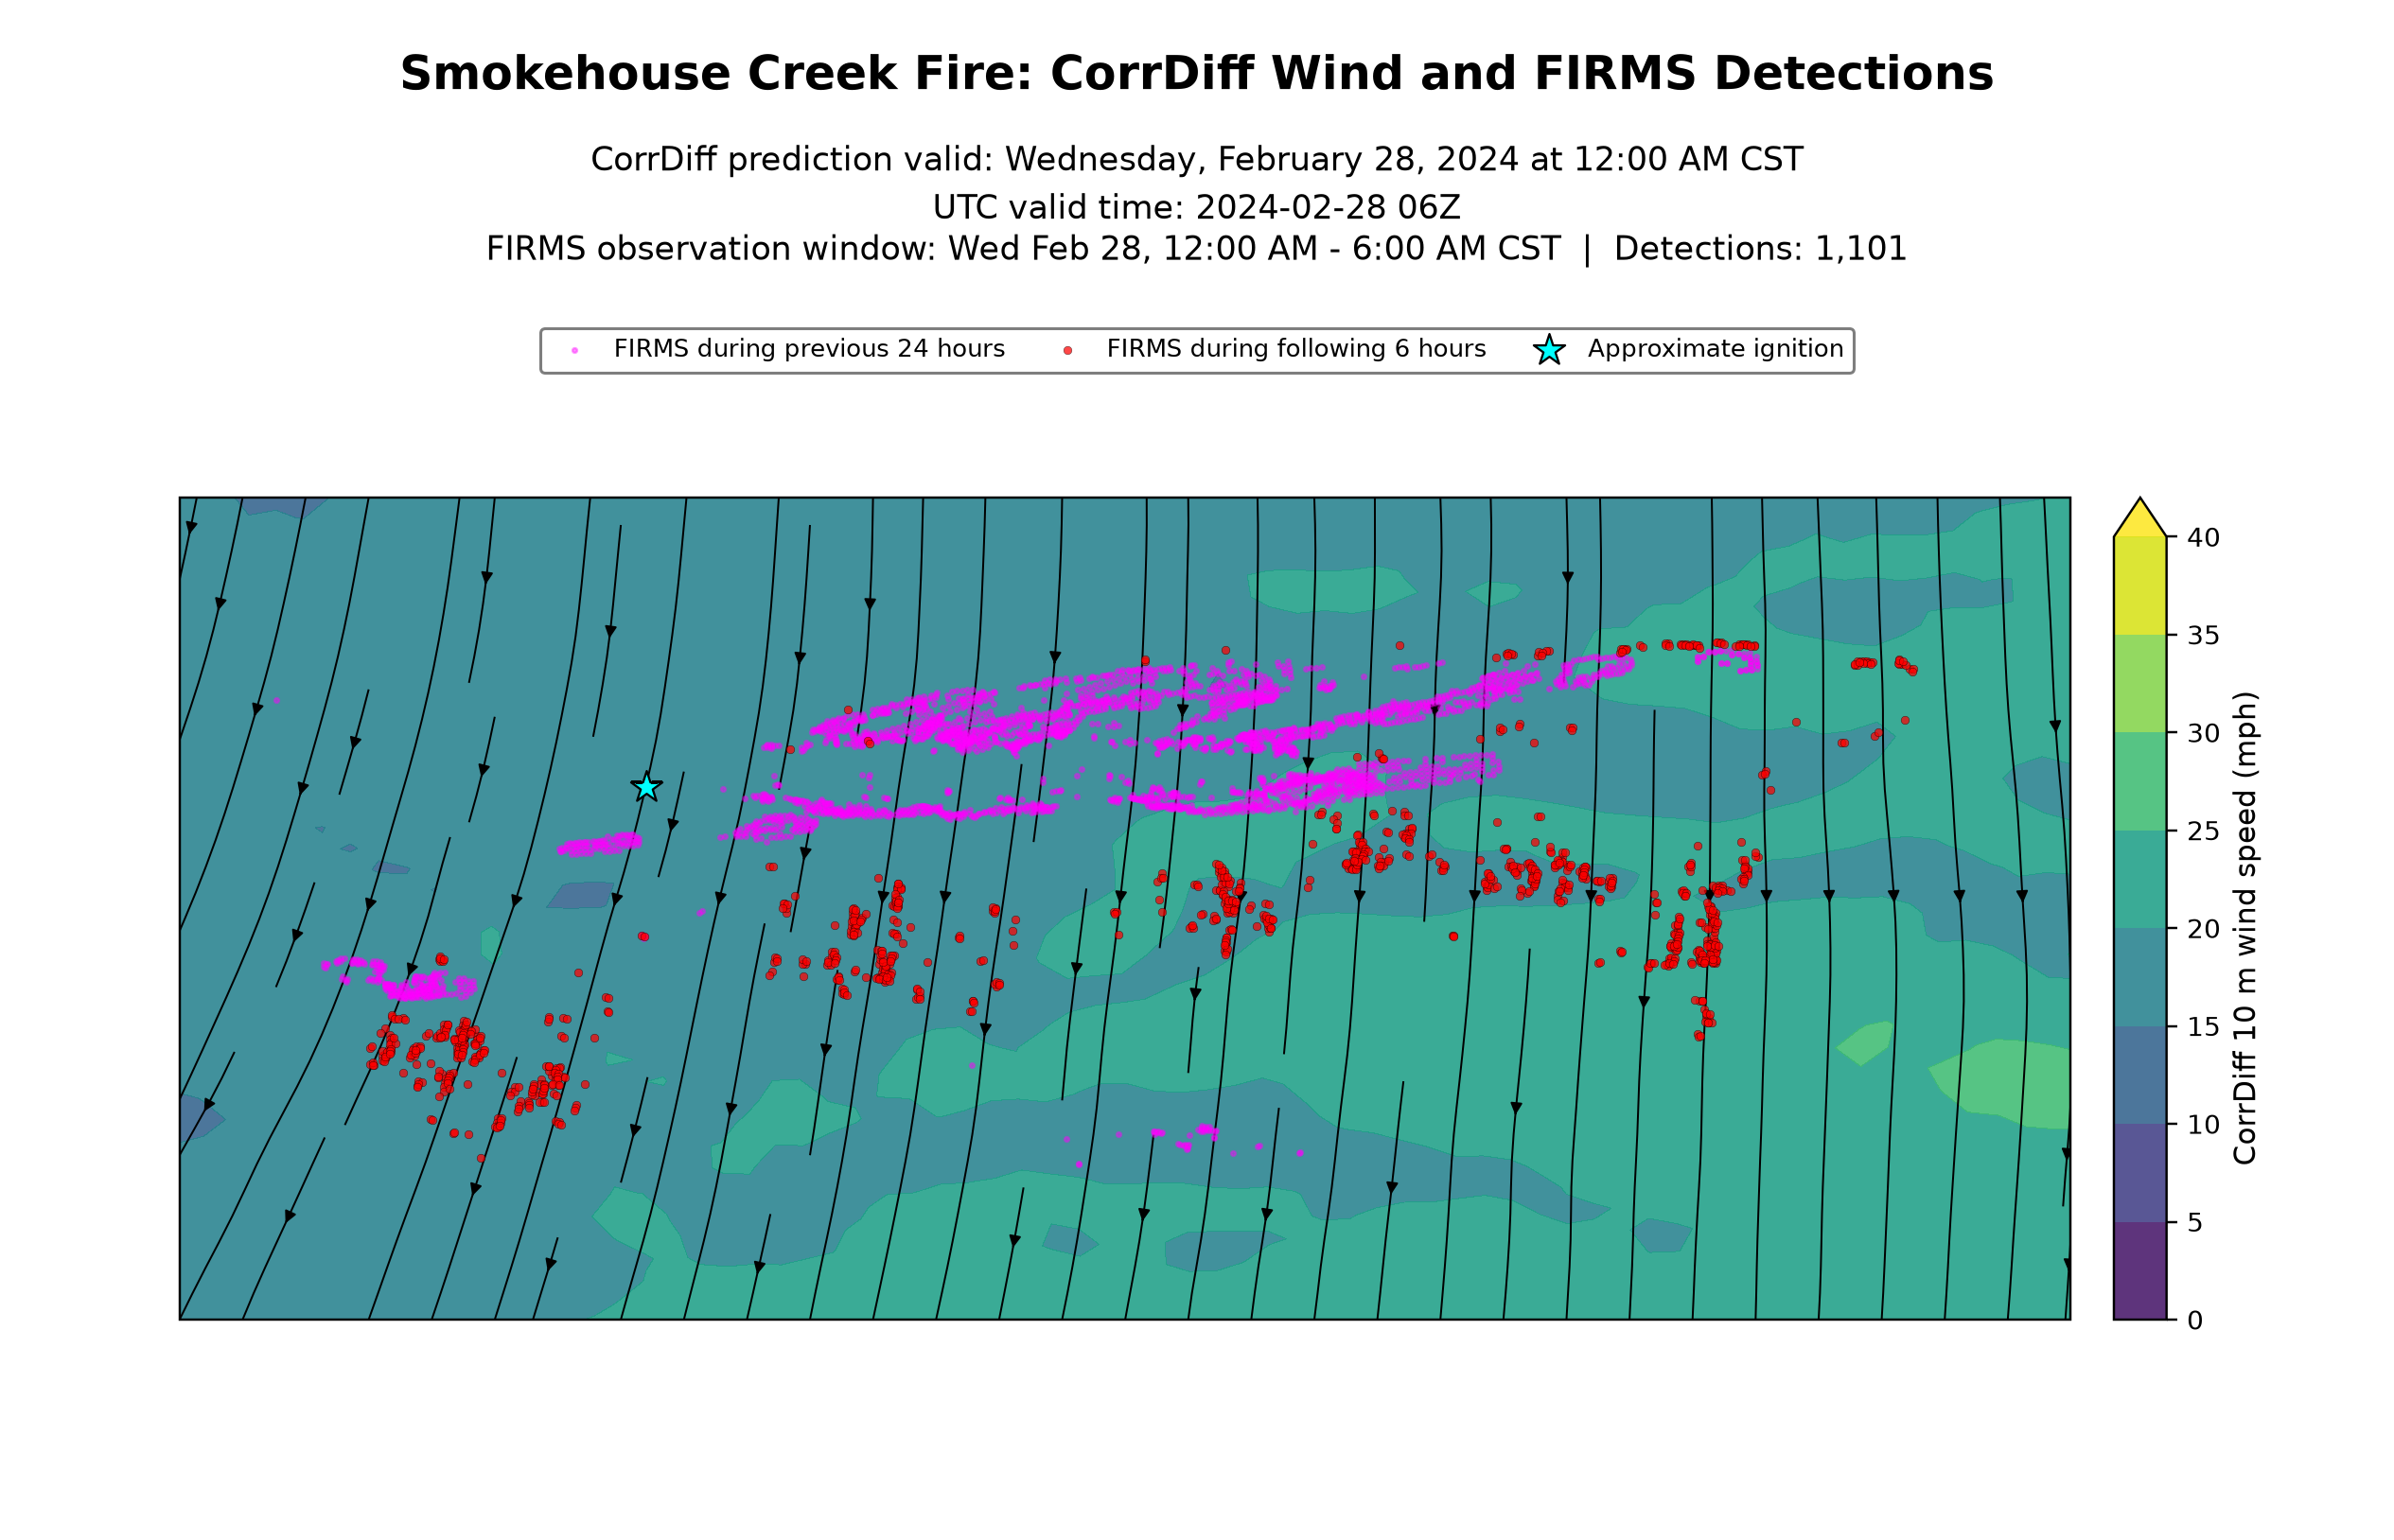

Saved 5/5: smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_2024-02-28_18Z.png


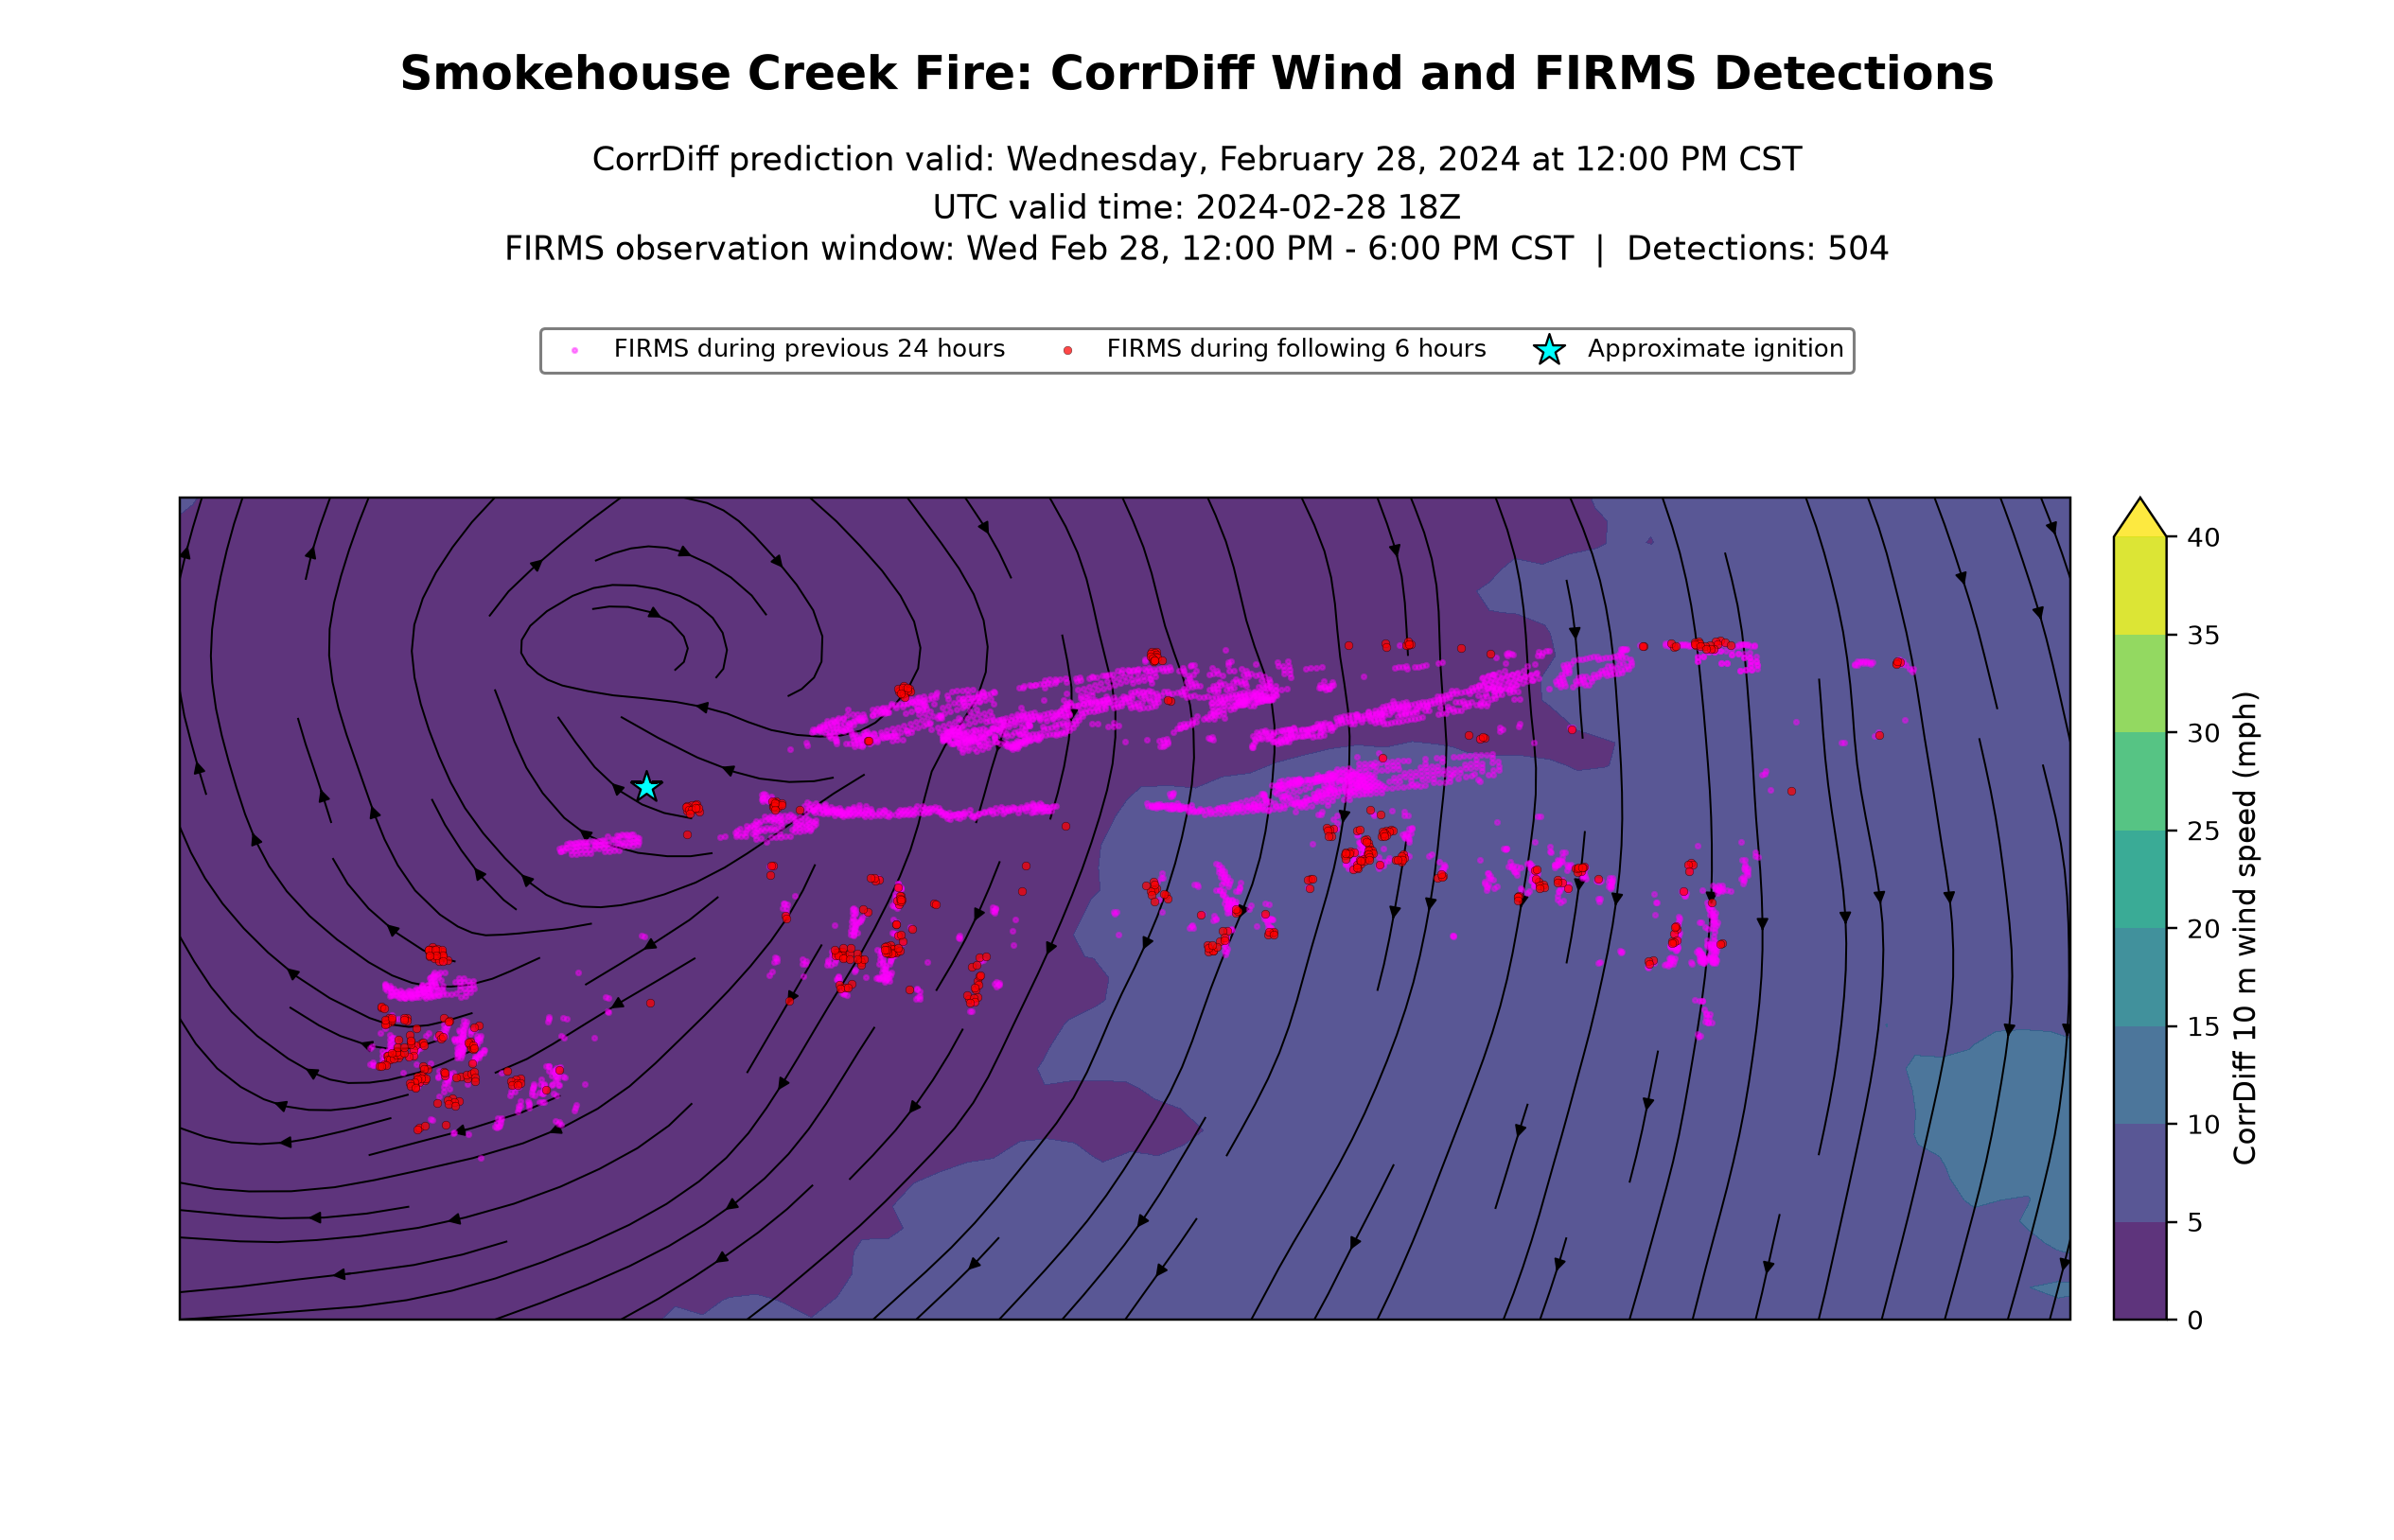


Finished. Saved 5 panels to:
/home/jovyan/Fires/smokehouse_creek_corrdiff_firms_panels


In [11]:
# ============================================================
# 7. Save and display one titled map for each valid time
# ============================================================

from IPython.display import display, Image
from scipy.interpolate import griddata


def safe_filename(label):
    return (
        str(label)
        .replace(":", "")
        .replace(" ", "_")
        .replace("/", "-")
    )


def regrid_wind_for_streamplot(
    lon_curved,
    lat_curved,
    u_curved,
    v_curved,
    nx=150,
    ny=90,
):
    """Interpolate curvilinear winds to a regular grid for streamplot."""

    valid = (
        np.isfinite(lon_curved)
        & np.isfinite(lat_curved)
        & np.isfinite(u_curved)
        & np.isfinite(v_curved)
    )

    if valid.sum() < 4:
        raise ValueError(
            "Not enough valid CorrDiff grid points to create streamlines."
        )

    source_points = np.column_stack(
        [
            lon_curved[valid],
            lat_curved[valid],
        ]
    )

    lon_regular = np.linspace(WEST, EAST, nx)
    lat_regular = np.linspace(SOUTH, NORTH, ny)

    lon_mesh, lat_mesh = np.meshgrid(
        lon_regular,
        lat_regular,
    )

    u_regular = griddata(
        source_points,
        u_curved[valid],
        (lon_mesh, lat_mesh),
        method="linear",
    )

    v_regular = griddata(
        source_points,
        v_curved[valid],
        (lon_mesh, lat_mesh),
        method="linear",
    )

    missing = (
        ~np.isfinite(u_regular)
        | ~np.isfinite(v_regular)
    )

    if missing.any():
        u_nearest = griddata(
            source_points,
            u_curved[valid],
            (lon_mesh, lat_mesh),
            method="nearest",
        )

        v_nearest = griddata(
            source_points,
            v_curved[valid],
            (lon_mesh, lat_mesh),
            method="nearest",
        )

        u_regular[missing] = u_nearest[missing]
        v_regular[missing] = v_nearest[missing]

    return (
        lon_regular,
        lat_regular,
        u_regular,
        v_regular,
    )


def plot_and_save_single_period(label, output_directory):
    frame_index = time_to_index[label]

    lon_zoom, lat_zoom, u_zoom, v_zoom, speed_zoom = crop_wind(
        u_frames[frame_index],
        v_frames[frame_index],
    )

    previous, future, start, end = firms_forward_window(label)

    # --------------------------------------------------------
    # Create the figure
    # --------------------------------------------------------

    fig = plt.figure(
        figsize=(11.5, 7.4),
        dpi=140,
        constrained_layout=False,
    )

    # Extra space is reserved above the map for the title,
    # timing information, and legend.
    fig.subplots_adjust(
        left=0.075,
        right=0.865,
        bottom=0.10,
        top=0.72,
    )

    ax = fig.add_subplot(
        1,
        1,
        1,
        projection=MAP_CRS,
    )

    ax.set_extent(
        [WEST, EAST, SOUTH, NORTH],
        crs=DATA_CRS,
    )

    # --------------------------------------------------------
    # CorrDiff wind-speed background
    # --------------------------------------------------------

    contour = ax.contourf(
        lon_zoom,
        lat_zoom,
        speed_zoom,
        levels=levels,
        extend="max",
        alpha=0.88,
        transform=DATA_CRS,
        zorder=1,
    )

    # --------------------------------------------------------
    # Wind streamlines
    # --------------------------------------------------------

    (
        stream_lon,
        stream_lat,
        stream_u,
        stream_v,
    ) = regrid_wind_for_streamplot(
        lon_zoom,
        lat_zoom,
        u_zoom,
        v_zoom,
    )

    ax.streamplot(
        stream_lon,
        stream_lat,
        stream_u,
        stream_v,
        density=STREAM_DENSITY,
        linewidth=STREAM_LINEWIDTH,
        arrowsize=STREAM_ARROWSIZE,
        color="black",
        transform=DATA_CRS,
        zorder=4,
    )

    # --------------------------------------------------------
    # Previous FIRMS detections
    # --------------------------------------------------------

    if len(previous):
        ax.scatter(
            previous["longitude"],
            previous["latitude"],
            s=PREVIOUS_POINT_SIZE,
            color="magenta",
            alpha=0.40,
            linewidth=0.8,
            transform=DATA_CRS,
            label=(
                f"FIRMS during previous "
                f"{PREVIOUS_HISTORY_HOURS} hours"
            ),
            zorder=5,
        )

    # --------------------------------------------------------
    # Following FIRMS detections
    # --------------------------------------------------------

    if len(future):
        ax.scatter(
            future["longitude"],
            future["latitude"],
            s=FUTURE_POINT_SIZE,
            color="red",
            alpha=0.72,
            edgecolor="black",
            linewidth=0.15,
            transform=DATA_CRS,
            label="FIRMS during following 6 hours",
            zorder=6,
        )

    # --------------------------------------------------------
    # Approximate ignition location
    # --------------------------------------------------------

    ax.scatter(
        FIRE_LON,
        FIRE_LAT,
        marker="*",
        s=130,
        color="cyan",
        edgecolor="black",
        linewidth=0.75,
        transform=DATA_CRS,
        label="Approximate ignition",
        zorder=7,
    )

    # Uncomment this if you want state lines, coastlines, etc.
    # add_map_features(ax)

    # --------------------------------------------------------
    # Title and valid-time information
    # --------------------------------------------------------

    prediction_local = start.tz_convert(LOCAL_TZ)

    prediction_date = (
        prediction_local
        .strftime("%A, %B %d, %Y")
        .replace(" 0", " ")
    )

    prediction_time = (
        prediction_local
        .strftime("%I:%M %p %Z")
        .lstrip("0")
    )

    prediction_utc = start.strftime("%Y-%m-%d %HZ")
    window_text = format_local_window(start, end)

    fig.text(
        0.50,
        0.965,
        "Smokehouse Creek Fire: CorrDiff Wind and FIRMS Detections",
        ha="center",
        va="top",
        fontsize=16,
        fontweight="bold",
    )

    fig.text(
        0.50,
        0.910,
        (
            f"CorrDiff prediction valid: "
            f"{prediction_date} at {prediction_time}\n"
            f"UTC valid time: {prediction_utc}\n"
            f"FIRMS observation window: {window_text}"
            f"  |  Detections: {len(future):,}"
        ),
        ha="center",
        va="top",
        fontsize=11.5,
        linespacing=1.35,
    )

    # --------------------------------------------------------
    # Figure-level legend above the map
    # --------------------------------------------------------

    handles, legend_labels = ax.get_legend_handles_labels()

    if handles:
        fig.legend(
            handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.50, 0.795),
            ncol=3,
            fontsize=8.5,
            frameon=True,
            framealpha=0.95,
            edgecolor="#777777",
            columnspacing=1.5,
            handletextpad=0.6,
        )

    # --------------------------------------------------------
    # Colorbar with exactly the same height as the map
    # --------------------------------------------------------

    # Cartopy may resize the map to preserve its geographic
    # aspect ratio. Drawing the figure first gives us the map's
    # actual final position.
    fig.canvas.draw()

    map_position = ax.get_position()

    colorbar_gap = 0.018
    colorbar_width = 0.022

    colorbar_axis = fig.add_axes(
        [
            map_position.x1 + colorbar_gap,
            map_position.y0,
            colorbar_width,
            map_position.height,
        ]
    )

    colorbar = fig.colorbar(
        contour,
        cax=colorbar_axis,
    )

    colorbar.set_label(
        "CorrDiff 10 m wind speed (mph)",
        fontsize=10,
    )

    colorbar.ax.tick_params(
        labelsize=9,
    )

    # --------------------------------------------------------
    # Save the finished figure
    # --------------------------------------------------------

    output_path = (
        output_directory
        / f"smokehouse_creek_{safe_filename(label)}.png"
    )

    fig.savefig(
        output_path,
        dpi=PANEL_DPI,
        pad_inches=0.25,
        facecolor="white",
    )

    plt.close(fig)

    return output_path


# ============================================================
# Generate all selected panels
# ============================================================

saved_panel_paths = []

for panel_number, label in enumerate(
    selected_labels,
    start=1,
):
    output_path = plot_and_save_single_period(
        label,
        PANEL_OUTPUT_DIR,
    )

    saved_panel_paths.append(output_path)

    print(
        f"Saved {panel_number}/{len(selected_labels)}: "
        f"{output_path}"
    )

    if DISPLAY_ALL_PANELS:
        display(
            Image(
                data=output_path.read_bytes(),
                width=DISPLAY_WIDTH,
            )
        )

print(
    f"\nFinished. Saved {len(saved_panel_paths)} panels to:"
)

print(PANEL_OUTPUT_DIR.resolve())

GIF saved to:
/home/jovyan/Fires/smokehouse_creek_corrdiff_firms_panels/smokehouse_creek_corrdiff_firms_animation.gif


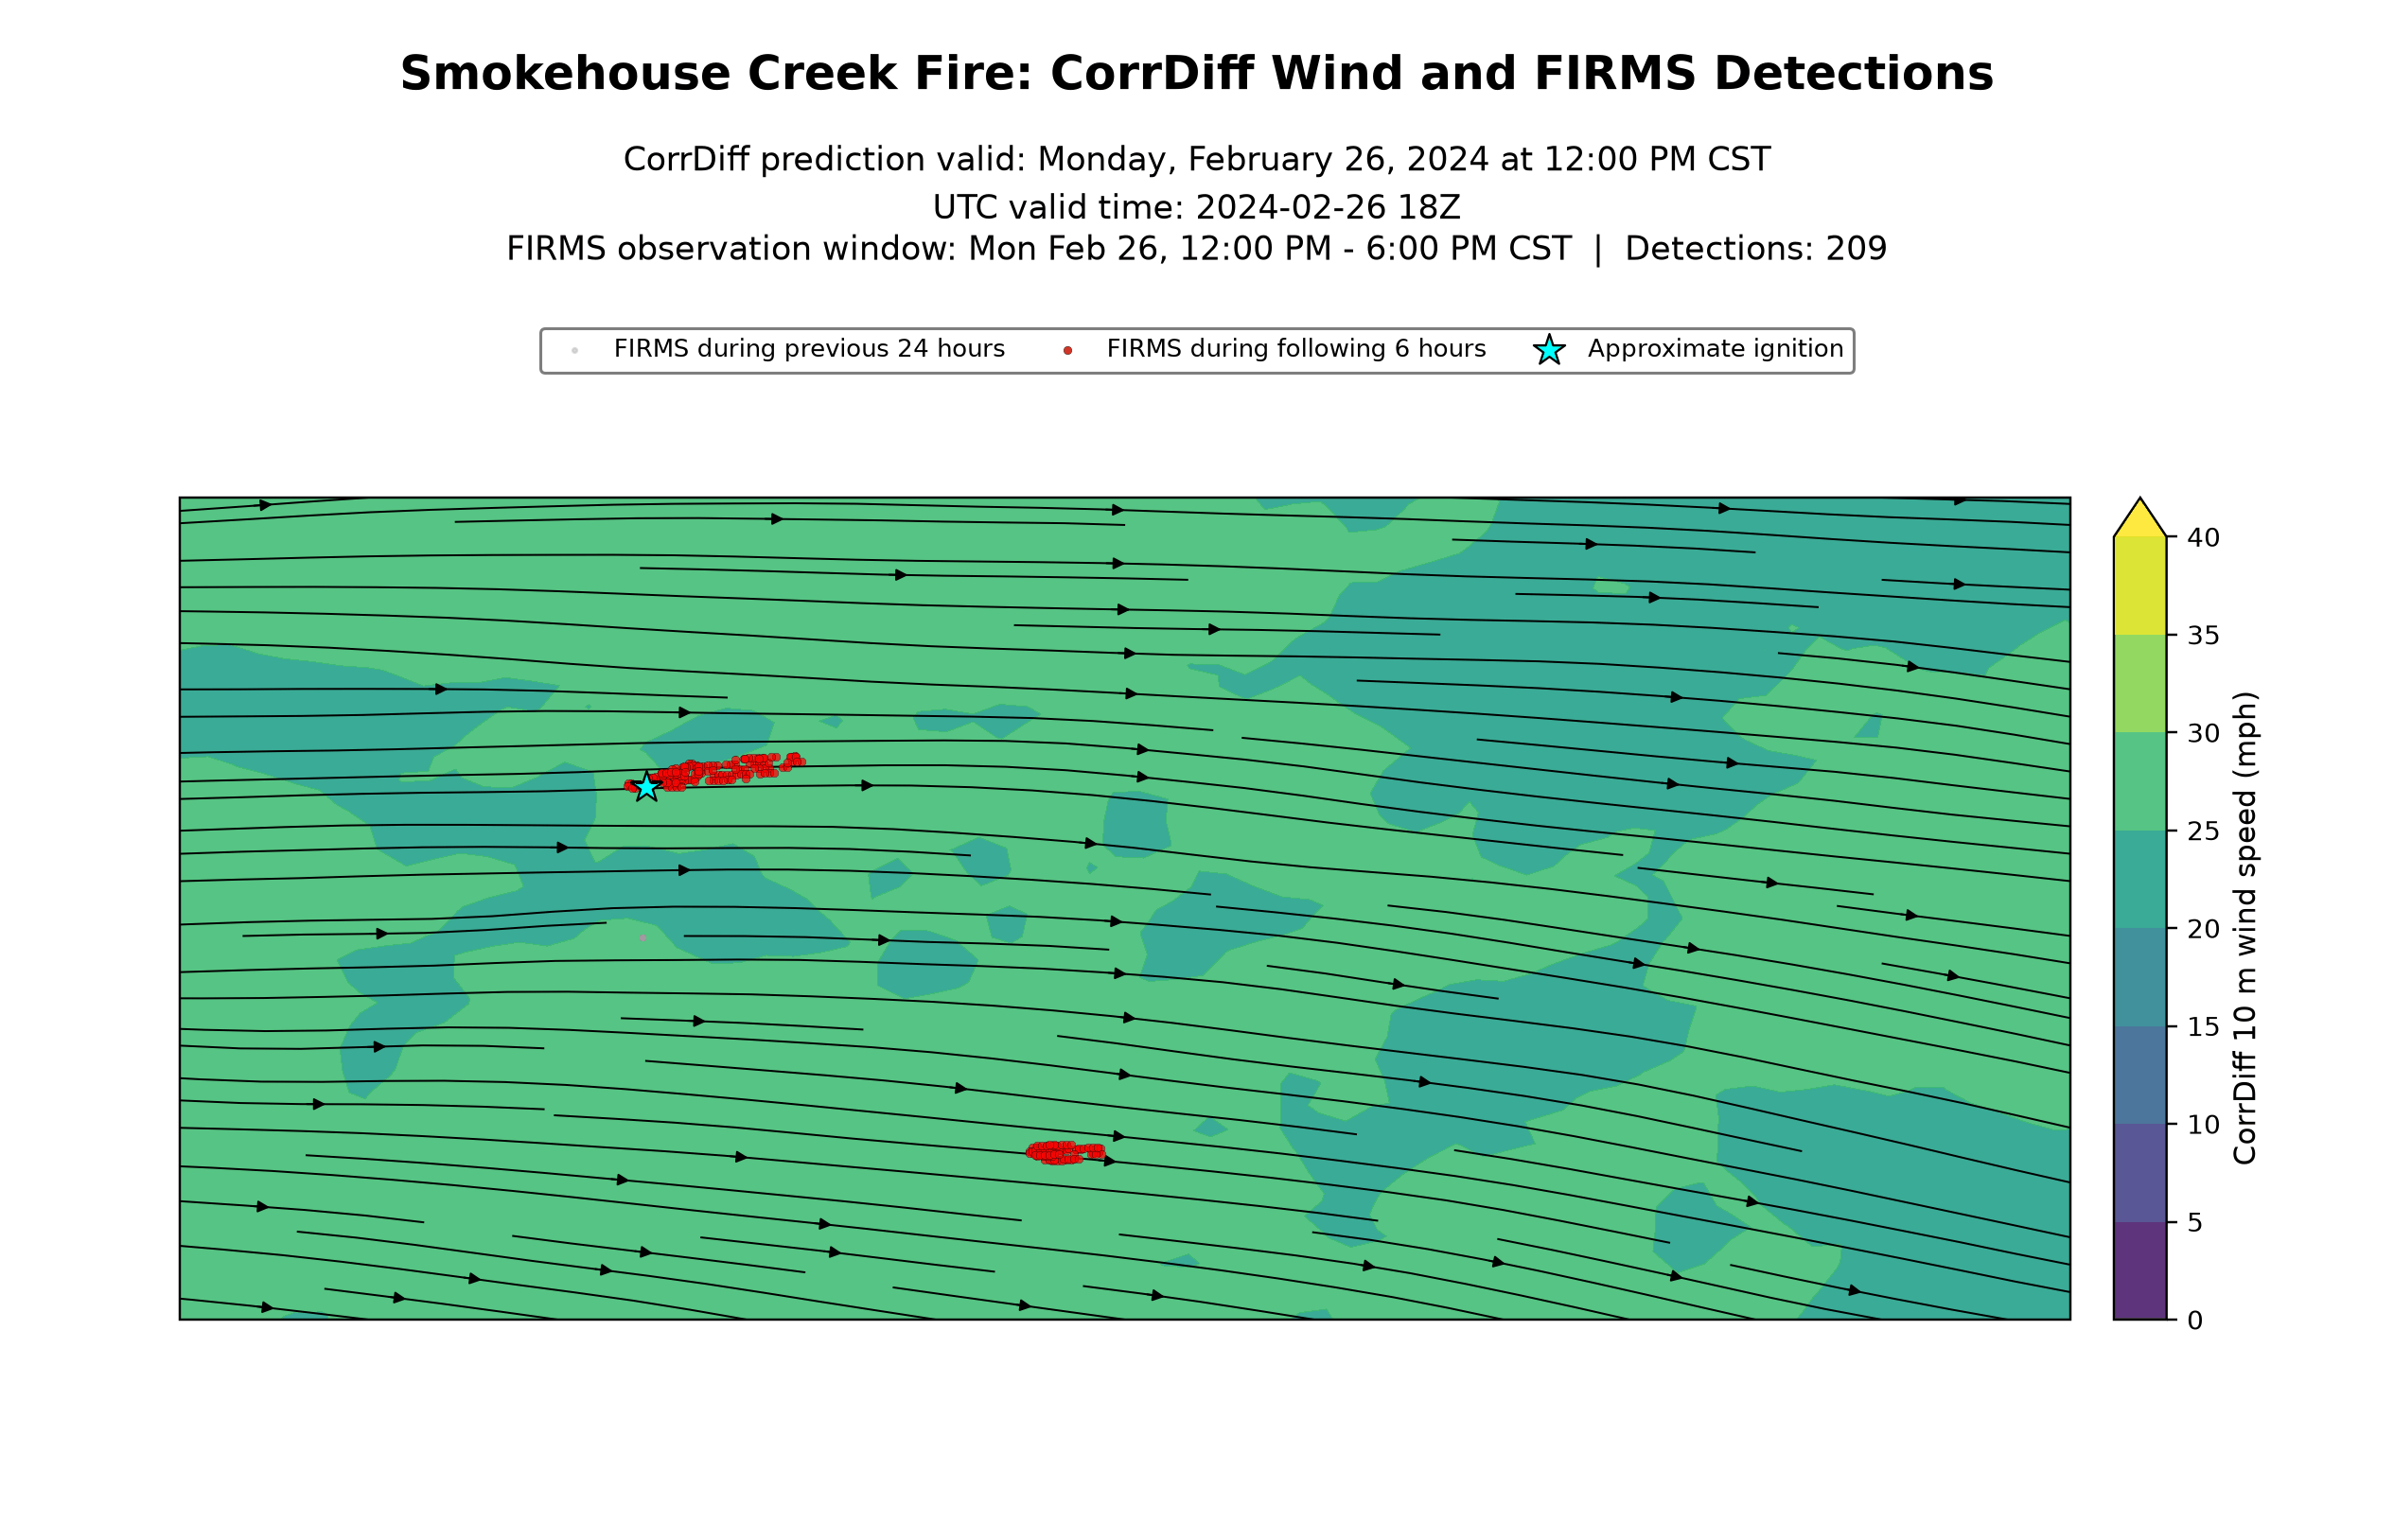

In [12]:
# ============================================================
# 8. Create an animated GIF from the saved Smokehouse panels
# ============================================================

from PIL import Image as PILImage, ImageOps
from IPython.display import display, Image

GIF_PATH = PANEL_OUTPUT_DIR / "smokehouse_creek_corrdiff_firms_animation.gif"
FRAME_DURATION_MS = 1000
HOLD_FIRST_FRAMES = 0
HOLD_LAST_FRAMES = 0

if "saved_panel_paths" in globals() and saved_panel_paths:
    image_paths = [Path(path) for path in saved_panel_paths]
else:
    image_paths = sorted(PANEL_OUTPUT_DIR.glob("smokehouse_creek_*.png"))

if not image_paths:
    raise ValueError(f"No PNG files were found in {PANEL_OUTPUT_DIR.resolve()}")

loaded_images = [PILImage.open(path).convert("RGB") for path in image_paths]
max_width = max(image.width for image in loaded_images)
max_height = max(image.height for image in loaded_images)

frames = [
    ImageOps.pad(
        image,
        size=(max_width, max_height),
        color="white",
        centering=(0.5, 0.5),
    )
    for image in loaded_images
]

animation_frames = (
    [frames[0].copy()] * HOLD_FIRST_FRAMES
    + frames
    + [frames[-1].copy()] * HOLD_LAST_FRAMES
)

animation_frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=animation_frames[1:],
    duration=FRAME_DURATION_MS,
    loop=0,
    disposal=2,
    optimize=False,
)

for image in loaded_images:
    image.close()

print("GIF saved to:")
print(GIF_PATH.resolve())
display(Image(data=GIF_PATH.read_bytes(), width=1000))